# HFE-7200 Viscosity Estimate from Recirculation Telemetry

    This notebook estimates the kinematic viscosity of the HFE-7200 charge as a function of temperature using:

    - a room-temperature reference formed from the two published room values in common kinematic-viscosity units,
    - the Seeton law used in `HFE_properties.ipynb` for the temperature-shape/reference curve,
    - measured pump-loop telemetry from the fixed-speed 40 % pump-command recirculation logs, and
    - 3M's low-temperature kinematic-viscosity points as a reference overlay, not as a low-temperature calibration of our telemetry.

    ## Room Reference

    The published room numbers mix units: the TDS gives dynamic viscosity, `μ(25 °C)=0.61 cP`, while the freezing-data table gives kinematic viscosity, `ν(25 °C)=0.41 cSt`. The notebook converts the TDS value to kinematic viscosity using the 3M density law at 25 °C, averages the two equivalent `ν(25 °C)` values, and carries half their separation as the room-reference error bar. That mean is shifted from 25 °C to the measured room-window temperature using only the local Seeton temperature dependence.

    ## Physical Scaling

    The first estimate is a pressure-drop proxy. For laminar flow through a fixed hydraulic geometry, the pump pressure rise satisfies

    $$ \Delta P = K_{	ext{geom}}\,\mu\,Q, $$

    so $(\Delta P / Q)$ is proportional to dynamic viscosity. The notebook anchors that proxy at the measured room-window temperature using the room-reference mean and measured Coriolis density:

    $$ \mu_{ref}=
u_{ref}
ho_{ref}, \qquad

u_i = 
u_{ref}\,
rac{
ho_{ref}}{
ho_i}\,
rac{(\Delta P_i/Q_i)}{(\Delta P/Q)_{ref}}. $$

    The second estimate uses gear-pump slip at fixed shaft speed. It is computed once from pooled bin medians, with one empirical fixed-speed displacement flow and one propagated displacement/flow-scale uncertainty.

    ## Operating-State Filters

    Samples are filtered to keep the same hydraulic operating state as much as possible:

    - pump command fixed at 40 %,
    - pump running with valid Coriolis density, positive flow and finite pressure rise,
    - fixed shaft speed for the pooled all-log comparison,
    - bypass-closed post-marker data for the 0424 cold-window diagnostic,
    - the 0417 fixed-speed samples are annotated as bypass-open in the pooled diagnostic section.

    The final comparison plot shows 3M's data, the Seeton law, the whole-loop `ΔP/Q` proxy, the tank-to-inlet `ΔP/Q` proxy, and the single simplified gear-pump slip estimate.

In [1]:
from pathlib import Path
import importlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.optimize import brentq, least_squares
from scipy.special import k0

import orca
import orca.logbook as orca_logbook

warnings.filterwarnings(
    'ignore',
    message='FigureCanvasAgg is non-interactive, and thus cannot be shown',
    category=UserWarning,
)

orca = importlib.reload(orca)
orca_logbook = importlib.reload(orca_logbook)

NB_PATH = Path.cwd()
REPO_ROOT = NB_PATH
for candidate in [NB_PATH, *NB_PATH.parents]:
    if (candidate / 'data').exists() and (candidate / 'analysis').exists():
        REPO_ROOT = candidate
        break

RECIRCULATION_DIR = REPO_ROOT / 'data' / 'raw' / 'recirculation'
ROOM_LOG_PATH = RECIRCULATION_DIR / 'log_20260422_143345.csv'
COLD_LOG_PATH = RECIRCULATION_DIR / 'log_20260424_153546.csv'
TC_CALIBRATION_PATH = REPO_ROOT / 'data' / 'processed' / 'calibration' / 'TC_calibration_20260420.csv'
STATIC_PRESSURE_LOG_PATHS = [
    RECIRCULATION_DIR / 'log_20260330_161922.csv',
    RECIRCULATION_DIR / 'log_20260402_150754.csv',
    RECIRCULATION_DIR / 'log_20260403_115916.csv',
    RECIRCULATION_DIR / 'log_20260417_094053.csv',
    RECIRCULATION_DIR / 'log_20260422_143345.csv',
    RECIRCULATION_DIR / 'log_20260424_153546.csv',
]
DENSITY_BOUNDS_KG_M3 = (1200.0, 1800.0)

# ---- Anchor and filter constants ---------------------------------------------------
PUMP_CMD_PCT  = 40.0
PUMP_CMD_TOL  = 0.25
ROOM_TEMP_BOUNDS_C = (20.0, 26.0)
ROOM_LOG_BYPASS_OPEN_MIN   = 285.5    # from the matching review notebook
ROOM_LOG_BYPASS_CLOSED_MIN = 301.95

# ---- Tank-to-pump-inlet pressure correction ---------------------------------------
G_ACCEL_M_S2 = 9.80665
BAR_PER_PA = 1.0e-5
TANK_INLET_STATIC_MAX_FLOW_LMIN = 0.05
TANK_INLET_STATIC_MIN_SAMPLES = 20
TANK_INLET_HEIGHT_OVERRIDE_M = None   # set to a measured tank-above-inlet height to override the pump-off fit

# ---- HFE_properties Seeton viscosity law ------------------------------------------
SEETON_MIN_VISCOSITY_CST = 0.04
SEETON_BESSEL_OFFSET_CST = 1.244067


def hfe7200_3m_density_g_ml(temperature_c):
    """3M linear density law used only for reference overlays."""
    return (
        orca_logbook.HFE_7200_DENSITY_INTERCEPT_G_ML
        - orca_logbook.HFE_7200_DENSITY_SLOPE_G_ML_PER_C * np.asarray(temperature_c, dtype=float)
    )


def hydrostatic_head_bar(rho_kg_m3, height_m):
    """Pressure increase from descending height_m through liquid of density rho."""
    return np.asarray(rho_kg_m3, dtype=float) * G_ACCEL_M_S2 * height_m * BAR_PER_PA


def seeton_viscosity_transform(viscosity_cst):
    """Seeton viscosity transform for kinematic viscosity in cSt."""
    viscosity_cst = np.asarray(viscosity_cst, dtype=float)
    correction = np.exp(-viscosity_cst) * k0(viscosity_cst + SEETON_BESSEL_OFFSET_CST)
    return np.log(np.log(viscosity_cst + 0.7 + correction))


def invert_seeton_transform(target_transform, high_start_cst):
    """Invert the Seeton transform numerically because the Bessel term has no closed-form inverse."""
    target_transform = float(target_transform)
    low_cst = SEETON_MIN_VISCOSITY_CST
    low_transform = float(seeton_viscosity_transform(low_cst))
    if target_transform < low_transform:
        raise ValueError('Seeton fit evaluated below the 0.04 cSt lower validity limit.')

    high_cst = max(float(high_start_cst), 2.0 * low_cst)
    while float(seeton_viscosity_transform(high_cst)) < target_transform:
        high_cst *= 2.0
        if high_cst > 1.0e8:
            raise RuntimeError('Could not bracket the Seeton viscosity inversion.')

    return brentq(
        lambda trial_cst: float(seeton_viscosity_transform(trial_cst)) - target_transform,
        low_cst,
        high_cst,
        xtol=1.0e-10,
        rtol=1.0e-10,
    )


def evaluate_seeton_viscosity(temperature_c, coefficient_a, coefficient_b, high_start_cst):
    temperature_c = np.asarray(temperature_c, dtype=float)
    temperature_k = temperature_c + 273.15
    target_transform = coefficient_a - coefficient_b * np.log(temperature_k)
    flat_result = [
        invert_seeton_transform(target_value, high_start_cst)
        for target_value in np.ravel(target_transform)
    ]
    return np.asarray(flat_result).reshape(target_transform.shape)


def fit_seeton_viscosity(temperature_c, viscosity_cst):
    """Fit ln(ln(nu + 0.7 + exp(-nu) K0(nu + 1.244067))) = A - B ln(T_K)."""
    temperature_c = np.asarray(temperature_c, dtype=float)
    temperature_k = temperature_c + 273.15
    viscosity_cst = np.asarray(viscosity_cst, dtype=float)
    high_start_cst = max(2.0 * float(np.max(viscosity_cst)), 1.0)

    transformed_viscosity = seeton_viscosity_transform(viscosity_cst)
    slope, intercept = np.polyfit(np.log(temperature_k), transformed_viscosity, 1)
    initial_guess = np.array([float(intercept), float(-slope)])

    def fitted_viscosity(params):
        coefficient_a, coefficient_b = params
        return evaluate_seeton_viscosity(temperature_c, coefficient_a, coefficient_b, high_start_cst)

    def log_residual(params):
        return np.log(fitted_viscosity(params)) - np.log(viscosity_cst)

    result = least_squares(log_residual, initial_guess)
    coefficient_a, coefficient_b = result.x

    def evaluate(new_temperature_c):
        return evaluate_seeton_viscosity(new_temperature_c, coefficient_a, coefficient_b, high_start_cst)

    params = {
        'A': float(coefficient_a),
        'B': float(coefficient_b),
        'log_rmse': float(np.sqrt(np.mean(log_residual(result.x) ** 2))),
    }
    return params, evaluate


ref_3m = orca_logbook.REFERENCE_3M_N7200.sort_values('temperature_c').copy()
ref_3m_T = ref_3m['temperature_c'].to_numpy(float)
ref_3m_nu = ref_3m['kinematic_viscosity_cSt'].to_numpy(float)
ref_3m_mu = ref_3m_nu * hfe7200_3m_density_g_ml(ref_3m_T)

T_ROOM_REFERENCE_C = 25.0
MU_TDS_ROOM_CP = 0.61
NU_FREEZING_TABLE_ROOM_CST = float(
    ref_3m.loc[ref_3m['temperature_c'].eq(T_ROOM_REFERENCE_C), 'kinematic_viscosity_cSt'].iloc[0]
)
RHO_3M_ROOM_REFERENCE_G_ML = float(hfe7200_3m_density_g_ml(T_ROOM_REFERENCE_C))
NU_TDS_ROOM_EQUIV_CST = MU_TDS_ROOM_CP / RHO_3M_ROOM_REFERENCE_G_ML
NU_ROOM_REFERENCE_SOURCE_VALUES_CST = np.array([
    NU_TDS_ROOM_EQUIV_CST,
    NU_FREEZING_TABLE_ROOM_CST,
])
NU_ROOM_REFERENCE_25C_CST = float(NU_ROOM_REFERENCE_SOURCE_VALUES_CST.mean())
NU_ROOM_REFERENCE_25C_ERR_CST = float(np.max(np.abs(
    NU_ROOM_REFERENCE_SOURCE_VALUES_CST - NU_ROOM_REFERENCE_25C_CST
)))

hfe7200_seeton_params, hfe7200_kinematic_viscosity_seeton_cSt = fit_seeton_viscosity(
    ref_3m_T,
    ref_3m_nu,
)
T_fine = np.linspace(-125.0, 30.0, 500)
nu_seeton_cSt = hfe7200_kinematic_viscosity_seeton_cSt(T_fine)

plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 180,
    'axes.grid': True,
    'grid.alpha': 0.28,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print(f'Repo root:    {REPO_ROOT}')
print(f'Room log:     {ROOM_LOG_PATH.name}')
print(f'Cold log:     {COLD_LOG_PATH.name}')
print(f'TC calibration: {TC_CALIBRATION_PATH.name}')
print(
    'Seeton law:   HFE_properties HFE-7200 fit, '
    f"A={hfe7200_seeton_params['A']:.3f}, B={hfe7200_seeton_params['B']:.3f}, "
    f"log RMSE={hfe7200_seeton_params['log_rmse']:.4f}"
)

Repo root:    /home/aamy/Documents/hfe-system
Room log:     log_20260422_143345.csv
Cold log:     log_20260424_153546.csv
TC calibration: TC_calibration_20260420.csv
Seeton law:   HFE_properties HFE-7200 fit, A=22.383, B=4.161, log RMSE=0.1056


## Load both logs and add a TC-mean bulk-temperature column

We use `orca.prepare_flow_log_review(..., tc_calibration_path=TC_CALIBRATION_PATH)` to get calibrated thermocouple columns and SI-converted columns (`density_kg_m3_si`, `volume_flow_lmin_si`, `delta_p_bar_recomputed`, `pump_running`, `t_min`). The flow meter has its own internal temperature sensor; for the cold run we additionally take the mean of the connected calibrated thermocouples as the bulk-temperature proxy because the flow meter saturates near `-94 °C`.

In [2]:
def load_with_bulk_temperature(log_path):
    review = orca.prepare_flow_log_review(log_path, density_bounds=DENSITY_BOUNDS_KG_M3, tc_calibration_path=TC_CALIBRATION_PATH)
    frame = review.data.copy().sort_values('time_s').reset_index(drop=True)
    if review.valid_temp_cols:
        frame['bulk_C'] = frame[list(review.valid_temp_cols)].mean(axis=1)
    else:
        frame['bulk_C'] = frame['temperature_c_si']
    frame['bulk_C'] = frame['bulk_C'].where(frame['bulk_C'].notna(), frame['temperature_c_si'])
    frame['log_name'] = log_path.name
    return review, frame

room_review, room_data = load_with_bulk_temperature(ROOM_LOG_PATH)
cold_review, cold_data = load_with_bulk_temperature(COLD_LOG_PATH)

print(f'Room log: {len(room_data):>5d} rows, valid TCs = {room_review.valid_temp_cols}')
print(f'Cold log: {len(cold_data):>5d} rows, valid TCs = {cold_review.valid_temp_cols}')

Room log: 11210 rows, valid TCs = ('TFO_C', 'TTI_C', 'TTO_C', 'TMI_C', 'THM_C', 'THI_C')
Cold log:  9467 rows, valid TCs = ('TFO_C', 'TTI_C', 'TTO_C', 'TMI_C', 'THM_C', 'THI_C')


## Step 1 — Calibrate $(\Delta P / Q)_{\text{ref}}$ from the 0422 room-temperature window

The reference window is the 40% pump-command, room-temperature segment of `log_20260422_143345.csv`. The bypass-open excursion (`285.5–301.95 min`) is excluded by construction because it lies after this room-temperature window finishes; we add an explicit guard anyway so that the filter is robust if the run is replayed.

We report median, mean and the 16/84 percentile spread for `ΔP`, `Q`, `ΔP/Q` and `ρ` in the window. The median is the value the cold scaling uses.

In [3]:
def select_room_anchor_window(frame):
    """40 % pump command, pump running, valid flow and density, bypass closed, room temperature."""
    bypass_excursion = frame['t_min'].between(ROOM_LOG_BYPASS_OPEN_MIN, ROOM_LOG_BYPASS_CLOSED_MIN)
    mask = (
        frame['pump_running']
        & frame['pump_cmd_pct'].sub(PUMP_CMD_PCT).abs().le(PUMP_CMD_TOL)
        & frame['volume_flow_lmin_si'].gt(0.0)
        & frame['delta_p_bar_recomputed'].gt(0.0)
        & frame['density_kg_m3_si'].between(*DENSITY_BOUNDS_KG_M3)
        & frame['temperature_c_si'].between(*ROOM_TEMP_BOUNDS_C)
        & ~bypass_excursion
    )
    return frame.loc[mask].copy()

room_anchor = select_room_anchor_window(room_data)
room_anchor['delta_p_per_q_bar_lmin'] = room_anchor['delta_p_bar_recomputed'] / room_anchor['volume_flow_lmin_si']

def _spread(series):
    series = pd.to_numeric(series, errors='coerce').dropna()
    return pd.Series({
        'median': float(series.median()),
        'mean':   float(series.mean()),
        'q16':    float(series.quantile(0.16)),
        'q84':    float(series.quantile(0.84)),
    })

anchor_summary = pd.DataFrame({
    'flow temperature [°C]': _spread(room_anchor['temperature_c_si']),
    'TC mean [°C]':          _spread(room_anchor['bulk_C']),
    'ΔP [bar]':              _spread(room_anchor['delta_p_bar_recomputed']),
    'Q [L/min]':             _spread(room_anchor['volume_flow_lmin_si']),
    'ΔP/Q [bar/(L/min)]':    _spread(room_anchor['delta_p_per_q_bar_lmin']),
    'ρ [kg/m³]':             _spread(room_anchor['density_kg_m3_si']),
    'pump freq [Hz]':        _spread(room_anchor['pump_freq_hz']),
}).T

DELTA_P_OVER_Q_REF = float(room_anchor['delta_p_per_q_bar_lmin'].median())
RHO_REF_KG_M3      = float(room_anchor['density_kg_m3_si'].median())
T_REF_C            = float(room_anchor['temperature_c_si'].median())
ROOM_REFERENCE_TEMP_SCALE = float(
    hfe7200_kinematic_viscosity_seeton_cSt(T_REF_C)
    / hfe7200_kinematic_viscosity_seeton_cSt(T_ROOM_REFERENCE_C)
)
NU_ROOM_ANCHOR_CST = NU_ROOM_REFERENCE_25C_CST * ROOM_REFERENCE_TEMP_SCALE
NU_ROOM_ANCHOR_ERR_CST = NU_ROOM_REFERENCE_25C_ERR_CST * ROOM_REFERENCE_TEMP_SCALE
MU_ROOM_ANCHOR_CP  = NU_ROOM_ANCHOR_CST * (RHO_REF_KG_M3 / 1000.0)  # cSt * g/mL = cP
MU_ROOM_ANCHOR_ERR_CP = NU_ROOM_ANCHOR_ERR_CST * (RHO_REF_KG_M3 / 1000.0)

room_reference_table = pd.DataFrame([
    {
        'source': 'TDS μ(25 °C)=0.61 cP → ν',
        'T [°C]': T_ROOM_REFERENCE_C,
        'ν [cSt]': NU_TDS_ROOM_EQUIV_CST,
        'note': f'converted with ρ_3M(25 °C)={RHO_3M_ROOM_REFERENCE_G_ML:.4f} g/mL',
    },
    {
        'source': 'freezing-data table ν(25 °C)',
        'T [°C]': T_ROOM_REFERENCE_C,
        'ν [cSt]': NU_FREEZING_TABLE_ROOM_CST,
        'note': 'direct kinematic-viscosity value',
    },
    {
        'source': 'room reference mean at 25 °C',
        'T [°C]': T_ROOM_REFERENCE_C,
        'ν [cSt]': NU_ROOM_REFERENCE_25C_CST,
        'note': f'±{NU_ROOM_REFERENCE_25C_ERR_CST:.4f} cSt half-range',
    },
    {
        'source': 'room-window anchor after Seeton local T correction',
        'T [°C]': T_REF_C,
        'ν [cSt]': NU_ROOM_ANCHOR_CST,
        'note': f'±{NU_ROOM_ANCHOR_ERR_CST:.4f} cSt; μ={MU_ROOM_ANCHOR_CP:.3f}±{MU_ROOM_ANCHOR_ERR_CP:.3f} cP using measured ρ_ref',
    },
])

def plot_room_reference(ax, *, label='room reference mean ± half-range', zorder=6, markersize=9):
    ax.errorbar(
        [T_REF_C], [NU_ROOM_ANCHOR_CST],
        yerr=[[NU_ROOM_ANCHOR_ERR_CST], [NU_ROOM_ANCHOR_ERR_CST]],
        fmt='*', color='#dc2626', ecolor='#dc2626', elinewidth=1.2,
        capsize=3.0, markersize=markersize, zorder=zorder, label=label,
    )

display(Markdown(
    f"Room anchor window: `{len(room_anchor)}` samples, `{float(room_anchor['t_min'].min()):.2f}–"
    f"{float(room_anchor['t_min'].max()):.2f} min` (well before the bypass-open excursion at "
    f"`{ROOM_LOG_BYPASS_OPEN_MIN:.1f} min`)."
))
display(anchor_summary.round(4))
display(room_reference_table.round({'T [°C]': 3, 'ν [cSt]': 4}))
display(Markdown(
    f"Reference values used downstream: `(ΔP/Q)_ref = {DELTA_P_OVER_Q_REF:.5f} bar/(L/min)`, "
    f"`ρ_ref = {RHO_REF_KG_M3:.1f} kg/m³` at `T_ref ≈ {T_REF_C:.2f} °C`. "
    f"The room anchor is the equivalent-source mean: `ν_ref = {NU_ROOM_ANCHOR_CST:.3f} ± "
    f"{NU_ROOM_ANCHOR_ERR_CST:.3f} cSt`; using measured `ρ_ref`, "
    f"that is `μ_ref = {MU_ROOM_ANCHOR_CP:.3f} ± {MU_ROOM_ANCHOR_ERR_CP:.3f} cP` for the internal dynamic-viscosity algebra."
))

Room anchor window: `107` samples, `264.77–268.45 min` (well before the bypass-open excursion at `285.5 min`).

,median,mean,q16,q84
flow temperature [°C],20.9020,20.8757,20.8559,20.9430
TC mean [°C],20.7416,20.6328,20.6539,20.8036
ΔP [bar],0.3180,0.3274,0.2490,0.4060
Q [L/min],2.5629,2.5375,2.5568,2.5686
ΔP/Q [bar/(L/min)],0.1273,0.1354,0.0974,0.1581
ρ [kg/m³],1434.9266,1435.0021,1434.8329,1435.0252
pump freq [Hz],28.1500,27.9079,28.1400,28.1500


,source,T [°C],ν [cSt],note
0,TDS μ(25 °C)=0.61 cP → ν,25.000,0.4285,converted with ρ_3M(25 °C)=1.4235 g/mL
1,freezing-data table ν(25 °C),25.000,0.4100,direct kinematic-viscosity value
2,room reference mean at 25 °C,25.000,0.4193,±0.0093 cSt half-range
3,room-window anchor after Seeton local T correc...,20.902,0.4405,±0.0097 cSt; μ=0.632±0.014 cP using measured ρ...


Reference values used downstream: `(ΔP/Q)_ref = 0.12732 bar/(L/min)`, `ρ_ref = 1434.9 kg/m³` at `T_ref ≈ 20.90 °C`. The room anchor is the equivalent-source mean: `ν_ref = 0.441 ± 0.010 cSt`; using measured `ρ_ref`, that is `μ_ref = 0.632 ± 0.014 cP` for the internal dynamic-viscosity algebra.

## Step 2 — Detect the bypass-closed marker on the 0424 cold log

The cold review notebook treats the first `40%`→`30%` pump-command transition as the moment the bypass is closed for the rest of the run. Reusing that detection here keeps the two analyses consistent and guarantees the cold samples we feed into the scaling share the same hydraulic path as the room anchor.

In [4]:
run = orca.segment_slice(cold_data, cold_review.segment_summary.loc[cold_review.run_segment_id])
_run_liquid, step_windows, _step_summary, _settle = orca.command_step_summary(run)
step_windows = step_windows.copy()

transition = (
    step_windows['cmd_pct'].shift(1).round().eq(PUMP_CMD_PCT)
    & step_windows['cmd_pct'].round().eq(30.0)
)
if not transition.any():
    raise RuntimeError('Could not find a 40 %→30 % pump-command transition in the cold log.')
BYPASS_CLOSED_TIME_S   = float(step_windows.loc[step_windows.index[transition][0], 'start_s'])
BYPASS_CLOSED_TIME_MIN = BYPASS_CLOSED_TIME_S / 60.0
print(f'Cold-log bypass-closed marker: {BYPASS_CLOSED_TIME_MIN:.2f} min '
      f'(time_s = {BYPASS_CLOSED_TIME_S:.1f}).')

Cold-log bypass-closed marker: 57.96 min (time_s = 3477.6).


## Step 3 — Estimate kinematic viscosity on the 0424 cold log

    Each cold sample at 40 % pump command after the bypass-closed marker is converted using the calibrated $(\Delta P / Q)_{	ext{ref}}$. Dynamic viscosity is only an internal intermediate; the notebook displays kinematic viscosity:

    $$ \mu_i = \mu_{	ext{ref}} \cdot 
rac{(\Delta P_i / Q_i)}{(\Delta P / Q)_{	ext{ref}}}, \qquad 
u_i = 
rac{\mu_i}{
ho_i}. $$

    The reference viscosity is the equivalent room-reference mean described above, shifted from 25 °C to the measured room-window temperature using only the local Seeton temperature dependence. We light-smooth $(\Delta P / Q)$ with a centered 120 s rolling median first to suppress sample-to-sample noise from instrument quantisation; the smoothing is the same on every sample so it does not bias the temperature dependence. Estimates are then summarised in 2.5 °C bulk-temperature bins.

In [5]:
SMOOTHING_WINDOW_S = 120.0
TEMP_BIN_WIDTH_C   = 2.5


def select_cold_window(frame):
    mask = (
        frame['pump_running']
        & frame['pump_cmd_pct'].sub(PUMP_CMD_PCT).abs().le(PUMP_CMD_TOL)
        & frame['time_s'].ge(BYPASS_CLOSED_TIME_S)
        & frame['volume_flow_lmin_si'].gt(0.0)
        & frame['delta_p_bar_recomputed'].gt(0.0)
        & frame['density_kg_m3_si'].between(*DENSITY_BOUNDS_KG_M3)
        & frame['bulk_C'].notna()
    )
    return frame.loc[mask].copy().sort_values('time_s').reset_index(drop=True)


def rolling_time_median(frame, column, window_s):
    series = pd.Series(
        pd.to_numeric(frame[column], errors='coerce').to_numpy(float),
        index=pd.to_timedelta(frame['time_s'].to_numpy(float), unit='s'),
    )
    return series.rolling(f'{window_s:.0f}s', center=True, min_periods=10).median().to_numpy()

cold = select_cold_window(cold_data)
cold['delta_p_per_q_bar_lmin'] = cold['delta_p_bar_recomputed'] / cold['volume_flow_lmin_si']
cold['delta_p_per_q_smoothed'] = rolling_time_median(cold, 'delta_p_per_q_bar_lmin', SMOOTHING_WINDOW_S)

ratio = cold['delta_p_per_q_smoothed'] / DELTA_P_OVER_Q_REF
cold['mu_est_cP'] = MU_ROOM_ANCHOR_CP * ratio
cold['nu_est_cSt'] = cold['mu_est_cP'] / (cold['density_kg_m3_si'] / 1000.0)

# Anchor sample at the room reference for the same scaling, by construction.
anchor_row = pd.DataFrame({
    'bulk_C': [T_REF_C],
    'mu_est_cP': [MU_ROOM_ANCHOR_CP],
    'nu_est_cSt': [NU_ROOM_ANCHOR_CST],
})

bins = np.arange(-115.0, 30.0 + TEMP_BIN_WIDTH_C, TEMP_BIN_WIDTH_C)
cold['temp_bin_C'] = pd.cut(cold['bulk_C'], bins=bins, include_lowest=True)
binned = (
    cold.dropna(subset=['mu_est_cP', 'nu_est_cSt'])
        .groupby('temp_bin_C', observed=True)
        .agg(
            samples=('time_s', 'size'),
            T_C=('bulk_C', 'median'),
            mu_median_cP=('mu_est_cP', 'median'),
            mu_q16_cP=('mu_est_cP', lambda s: s.quantile(0.16)),
            mu_q84_cP=('mu_est_cP', lambda s: s.quantile(0.84)),
            nu_median_cSt=('nu_est_cSt', 'median'),
            nu_q16_cSt=('nu_est_cSt', lambda s: s.quantile(0.16)),
            nu_q84_cSt=('nu_est_cSt', lambda s: s.quantile(0.84)),
            rho_median=('density_kg_m3_si', 'median'),
        )
)
binned = binned[binned['samples'].ge(20)].reset_index(drop=True)

display(Markdown(
    f"Cold window: `{len(cold)}` samples at `{PUMP_CMD_PCT:.0f}%` pump command after the bypass-closed marker, "
    f"covering `{float(cold['bulk_C'].min()):.1f}` to `{float(cold['bulk_C'].max()):.1f} °C`. "
    f"Binned to `{TEMP_BIN_WIDTH_C:.1f} °C` and requiring `≥20` samples per bin."
))
display(binned[[
    'samples', 'T_C',
    'nu_median_cSt', 'nu_q16_cSt', 'nu_q84_cSt',
    'rho_median',
]].round(3))

Cold window: `6389` samples at `40%` pump command after the bypass-closed marker, covering `-102.7` to `-27.7 °C`. Binned to `2.5 °C` and requiring `≥20` samples per bin.

,samples,T_C,nu_median_cSt,nu_q16_cSt,nu_q84_cSt,rho_median
0,762,-101.431,1.231,1.141,1.340,1669.0
1,452,-98.698,1.139,1.055,1.276,1666.0
2,419,-95.965,0.998,0.920,1.085,1657.0
3,310,-93.903,0.915,0.875,0.989,1648.0
4,295,-91.294,0.864,0.798,0.962,1642.0
5,251,-88.798,0.857,0.791,0.948,1642.0
6,201,-86.209,0.830,0.743,0.880,1639.0
7,200,-83.825,0.827,0.698,0.863,1637.5
8,171,-81.307,0.791,0.671,0.857,1632.0
9,136,-78.884,0.760,0.699,0.791,1634.0


## Step 3b — Tank-to-pump-inlet pressure loss as a second loop proxy

The tank and pump inlet are much closer than the full pump-discharge loop, so this is a useful cross-check. The raw channel is not simply `P_tank − P_inlet`, though: the tank is vertically above the pump inlet, so at zero flow the lower inlet should read higher by the hydrostatic head, plus any fixed sensor offset.

We therefore estimate the no-flow static relation from pump-off/liquid samples,

$$ (P_{inlet}-P_{tank})_{static} = P_{offset} + \rho g h, $$

and define the running suction-line pressure loss as

$$ \Delta P_{tank\to inlet} = (P_{inlet}-P_{tank})_{static} - (P_{inlet}-P_{tank})_{running}. $$

If you measure the vertical separation directly, set `TANK_INLET_HEIGHT_OVERRIDE_M` in the setup cell and rerun; otherwise the notebook fits the effective height from the available pump-off data. The resulting viscosity estimate is still a single-anchor `ΔP/Q` scaling, so it is a diagnostic rather than the preferred pump-slip estimate.

Static tank-to-inlet correction source: **pump-off fit**. The fitted relation is `P_inlet − P_tank = 0.058 bar + ρ g (0.93 m)`. For HFE density this static term is about `0.195 bar` at 1500 kg/m³.

Room anchor for this proxy: `97` positive-loss samples, `(ΔP_tank→inlet/Q)_ref = 0.03577 bar/(L/min)`. The cold filter keeps `5920` positive-loss samples and drops `7.3%` as non-physical/noise-crossing losses.

,log,samples,rho_median,inlet_minus_tank_median_bar,q16_bar,q84_bar,note
0,log_20260330_161922.csv,2853,1437.0,0.205,0.117,0.273,used
1,log_20260402_150754.csv,1509,1437.3,0.195,0.097,0.264,used
2,log_20260403_115916.csv,649,1436.4,0.166,0.088,0.234,used
3,log_20260417_094053.csv,646,1476.2,0.156,0.078,0.234,used
4,log_20260422_143345.csv,6680,1473.8,0.195,0.126,0.263,used
5,log_20260424_153546.csv,1633,1514.0,0.215,0.147,0.273,used


,samples,rho_kg_m3,inlet_minus_tank_bar
0,5113,1437.1,0.195
1,3635,1460.0,0.185
2,2205,1484.7,0.186
3,2285,1512.1,0.205
4,730,1530.4,0.195


,samples,T_C,loss_median_bar,loss_q16_bar,loss_q84_bar,nu_median_cSt,nu_q16_cSt,nu_q84_cSt
0,742,-101.441,0.357,0.201,0.590,1.381,1.261,1.490
1,425,-98.740,0.366,0.171,0.619,1.407,1.306,1.484
2,366,-95.958,0.365,0.150,0.556,1.454,1.316,1.548
3,277,-93.879,0.335,0.140,0.472,1.262,1.135,1.459
4,279,-91.294,0.267,0.090,0.422,1.043,0.983,1.359
5,233,-88.759,0.246,0.120,0.433,1.061,0.828,1.565
6,186,-86.192,0.264,0.109,0.425,1.020,0.842,1.290
7,188,-83.844,0.226,0.129,0.403,0.910,0.793,1.385
8,157,-81.324,0.244,0.110,0.393,0.870,0.828,1.325
9,126,-78.868,0.221,0.100,0.410,0.960,0.839,1.122


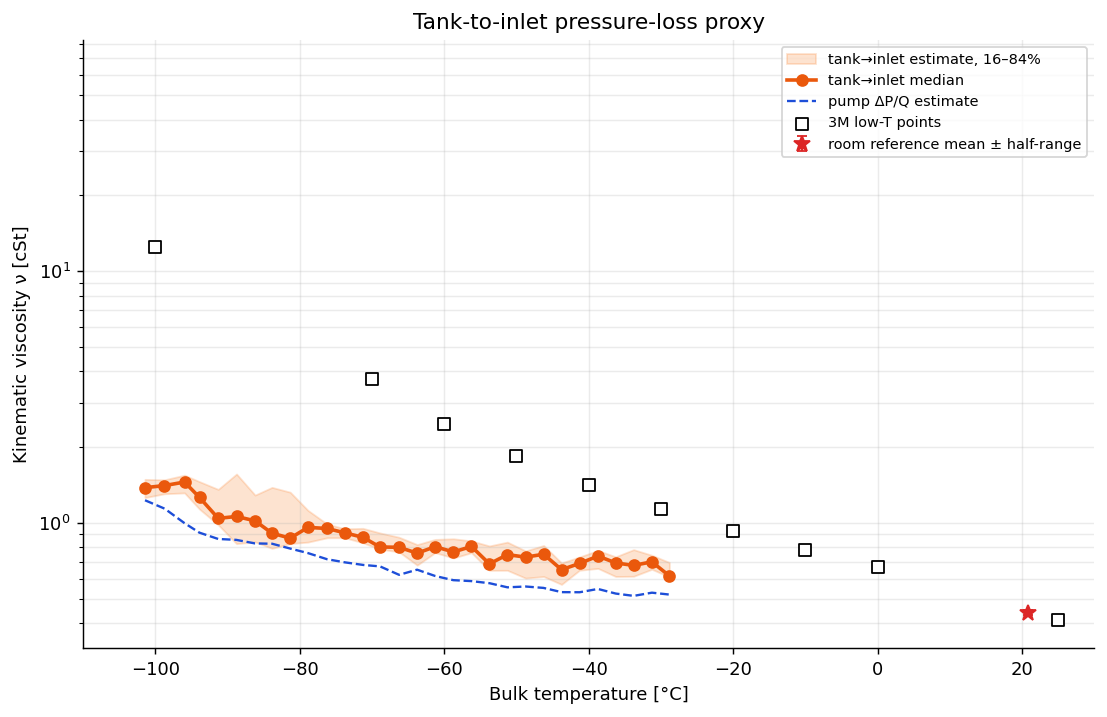

In [6]:
def collect_tank_inlet_static_samples(log_paths):
    sample_frames = []
    summary_rows = []
    for log_path in log_paths:
        try:
            _review, frame = load_with_bulk_temperature(log_path)
        except Exception as exc:  # keep the pressure-offset fit opportunistic
            summary_rows.append({'log': log_path.name, 'samples': 0, 'note': f'skipped: {exc}'})
            continue
        frame = frame.copy()
        frame['inlet_minus_tank_bar'] = (
            frame['pump_pressure_before_bar_abs'] - frame['pump_pressure_tank_bar_abs']
        )
        static_mask = (
            ~frame['pump_running']
            & frame['density_kg_m3_si'].between(*DENSITY_BOUNDS_KG_M3)
            & frame['volume_flow_lmin_si'].abs().lt(TANK_INLET_STATIC_MAX_FLOW_LMIN)
            & frame['inlet_minus_tank_bar'].notna()
        )
        samples = frame.loc[static_mask, ['density_kg_m3_si', 'inlet_minus_tank_bar', 'log_name', 't_min']].copy()
        if len(samples) >= TANK_INLET_STATIC_MIN_SAMPLES:
            sample_frames.append(samples)
            summary_rows.append({
                'log': log_path.name,
                'samples': len(samples),
                'rho_median': samples['density_kg_m3_si'].median(),
                'inlet_minus_tank_median_bar': samples['inlet_minus_tank_bar'].median(),
                'q16_bar': samples['inlet_minus_tank_bar'].quantile(0.16),
                'q84_bar': samples['inlet_minus_tank_bar'].quantile(0.84),
                'note': 'used',
            })
        else:
            summary_rows.append({'log': log_path.name, 'samples': len(samples), 'note': 'too few static liquid samples'})
    if not sample_frames:
        raise RuntimeError('No pump-off liquid samples found for the tank-to-inlet static correction.')
    return pd.concat(sample_frames, ignore_index=True), pd.DataFrame(summary_rows)


def fit_tank_inlet_static_model(static_samples):
    if TANK_INLET_HEIGHT_OVERRIDE_M is not None:
        height_m = float(TANK_INLET_HEIGHT_OVERRIDE_M)
        offset_bar = float(np.median(
            static_samples['inlet_minus_tank_bar']
            - hydrostatic_head_bar(static_samples['density_kg_m3_si'], height_m)
        ))
        fit_bins = pd.DataFrame()
        source = 'manual height override'
    else:
        rho_bins = np.arange(DENSITY_BOUNDS_KG_M3[0], DENSITY_BOUNDS_KG_M3[1] + 25.0, 25.0)
        fit_bins = (
            static_samples.assign(rho_bin_C=pd.cut(static_samples['density_kg_m3_si'], bins=rho_bins))
            .groupby('rho_bin_C', observed=True)
            .agg(
                samples=('inlet_minus_tank_bar', 'size'),
                rho_kg_m3=('density_kg_m3_si', 'median'),
                inlet_minus_tank_bar=('inlet_minus_tank_bar', 'median'),
            )
            .query('samples >= @TANK_INLET_STATIC_MIN_SAMPLES')
            .reset_index(drop=True)
        )
        if len(fit_bins) >= 2:
            design = np.column_stack([np.ones(len(fit_bins)), fit_bins['rho_kg_m3'].to_numpy(float)])
            offset_bar, slope_bar_per_kg_m3 = np.linalg.lstsq(
                design, fit_bins['inlet_minus_tank_bar'].to_numpy(float), rcond=None
            )[0]
            height_m = max(0.0, float(slope_bar_per_kg_m3) / (G_ACCEL_M_S2 * BAR_PER_PA))
            source = 'pump-off fit'
        else:
            height_m = 0.0
            offset_bar = float(static_samples['inlet_minus_tank_bar'].median())
            source = 'constant pump-off median'
    return float(offset_bar), float(height_m), fit_bins, source


static_samples, static_summary = collect_tank_inlet_static_samples(STATIC_PRESSURE_LOG_PATHS)
TANK_INLET_SENSOR_OFFSET_BAR, TANK_ABOVE_INLET_FIT_M, tank_static_fit_bins, static_source = fit_tank_inlet_static_model(static_samples)

def add_tank_inlet_loss(frame):
    out = frame.copy()
    out['tank_inlet_raw_bar'] = out['pump_pressure_before_bar_abs'] - out['pump_pressure_tank_bar_abs']
    out['tank_inlet_static_bar'] = (
        TANK_INLET_SENSOR_OFFSET_BAR
        + hydrostatic_head_bar(out['density_kg_m3_si'], TANK_ABOVE_INLET_FIT_M)
    )
    out['tank_inlet_loss_bar'] = out['tank_inlet_static_bar'] - out['tank_inlet_raw_bar']
    out['tank_inlet_loss_per_q_bar_lmin'] = out['tank_inlet_loss_bar'] / out['volume_flow_lmin_si']
    return out

room_tank = add_tank_inlet_loss(room_anchor)
cold_tank = add_tank_inlet_loss(cold)
room_tank_valid = room_tank[room_tank['tank_inlet_loss_bar'].gt(0.0)].copy()
cold_tank_valid = cold_tank[cold_tank['tank_inlet_loss_bar'].gt(0.0)].copy()

TANK_DELTA_P_OVER_Q_REF = float(room_tank_valid['tank_inlet_loss_per_q_bar_lmin'].median())
cold_tank_valid['tank_loss_per_q_smoothed'] = rolling_time_median(
    cold_tank_valid, 'tank_inlet_loss_per_q_bar_lmin', SMOOTHING_WINDOW_S
)
cold_tank_valid['mu_tank_inlet_cP'] = (
    MU_ROOM_ANCHOR_CP * cold_tank_valid['tank_loss_per_q_smoothed'] / TANK_DELTA_P_OVER_Q_REF
)
cold_tank_valid['nu_tank_inlet_cSt'] = cold_tank_valid['mu_tank_inlet_cP'] / (
    cold_tank_valid['density_kg_m3_si'] / 1000.0
)

cold_tank_valid['temp_bin_C'] = pd.cut(cold_tank_valid['bulk_C'], bins=bins, include_lowest=True)
tank_inlet_binned = (
    cold_tank_valid.dropna(subset=['mu_tank_inlet_cP', 'nu_tank_inlet_cSt'])
    .groupby('temp_bin_C', observed=True)
    .agg(
        samples=('time_s', 'size'),
        T_C=('bulk_C', 'median'),
        loss_median_bar=('tank_inlet_loss_bar', 'median'),
        loss_q16_bar=('tank_inlet_loss_bar', lambda s: s.quantile(0.16)),
        loss_q84_bar=('tank_inlet_loss_bar', lambda s: s.quantile(0.84)),
        mu_median_cP=('mu_tank_inlet_cP', 'median'),
        mu_q16_cP=('mu_tank_inlet_cP', lambda s: s.quantile(0.16)),
        mu_q84_cP=('mu_tank_inlet_cP', lambda s: s.quantile(0.84)),
        nu_median_cSt=('nu_tank_inlet_cSt', 'median'),
        nu_q16_cSt=('nu_tank_inlet_cSt', lambda s: s.quantile(0.16)),
        nu_q84_cSt=('nu_tank_inlet_cSt', lambda s: s.quantile(0.84)),
    )
    .query('samples >= 20')
    .reset_index(drop=True)
)


# Reference arrays for the diagnostic plot below. This cell appears before the main
# 3M-overlay plotting cell, so define them locally here.
ref_3m = orca_logbook.REFERENCE_3M_N7200.sort_values('temperature_c').copy()
ref_3m_T = ref_3m['temperature_c'].to_numpy(float)
ref_3m_nu = ref_3m['kinematic_viscosity_cSt'].to_numpy(float)
ref_3m_mu = ref_3m_nu * hfe7200_3m_density_g_ml(ref_3m_T)

display(Markdown(
    f"Static tank-to-inlet correction source: **{static_source}**. The fitted relation is "
    f"`P_inlet − P_tank = {TANK_INLET_SENSOR_OFFSET_BAR:.3f} bar + ρ g "
    f"({TANK_ABOVE_INLET_FIT_M:.2f} m)`. For HFE density this static term is about "
    f"`{TANK_INLET_SENSOR_OFFSET_BAR + hydrostatic_head_bar(1500.0, TANK_ABOVE_INLET_FIT_M):.3f} bar` at 1500 kg/m³.\n\n"
    f"Room anchor for this proxy: `{len(room_tank_valid)}` positive-loss samples, "
    f"`(ΔP_tank→inlet/Q)_ref = {TANK_DELTA_P_OVER_Q_REF:.5f} bar/(L/min)`. "
    f"The cold filter keeps `{len(cold_tank_valid)}` positive-loss samples and drops "
    f"`{100.0*(1.0 - len(cold_tank_valid)/max(len(cold_tank), 1)):.1f}%` as non-physical/noise-crossing losses."
))
display(static_summary.round({'rho_median': 1, 'inlet_minus_tank_median_bar': 3, 'q16_bar': 3, 'q84_bar': 3}))
if not tank_static_fit_bins.empty:
    display(tank_static_fit_bins.round({'rho_kg_m3': 1, 'inlet_minus_tank_bar': 3}))
display(tank_inlet_binned[[
    'samples', 'T_C',
    'loss_median_bar', 'loss_q16_bar', 'loss_q84_bar',
    'nu_median_cSt', 'nu_q16_cSt', 'nu_q84_cSt',
]].round(3))

fig, ax = plt.subplots(figsize=(8.4, 5.4), constrained_layout=True)
ax.fill_between(
    tank_inlet_binned['T_C'], tank_inlet_binned['nu_q16_cSt'], tank_inlet_binned['nu_q84_cSt'],
    color='#f97316', alpha=0.20, label='tank→inlet estimate, 16–84%',
)
ax.plot(
    tank_inlet_binned['T_C'], tank_inlet_binned['nu_median_cSt'],
    color='#ea580c', marker='o', lw=2.0, label='tank→inlet median',
)
ax.plot(
    binned['T_C'], binned['nu_median_cSt'],
    color='#1d4ed8', ls='--', lw=1.3, label='pump ΔP/Q estimate',
)
ax.scatter(ref_3m_T, ref_3m_nu, edgecolor='black', facecolor='white', s=38, marker='s', zorder=4,
           label='3M low-T points')
plot_room_reference(ax)
ax.set_yscale('log')
ax.set_xlim(-110.0, 30.0)
ax.set_xlabel('Bulk temperature [°C]')
ax.set_ylabel('Kinematic viscosity ν [cSt]')
ax.set_title('Tank-to-inlet pressure-loss proxy')
ax.grid(True, which='both', alpha=0.25)
ax.legend(loc='upper right', fontsize=8)
plt.show()

## Step 4 — Plot the estimate against the 3M low-temperature points

The 3M low-temperature kinematic-viscosity points stored in `orca.logbook.REFERENCE_3M_N7200` (originally tabulated in `analysis/docs/HFE Freezing Data.pdf`) are overlaid as a visual sanity check. They are not used as a low-temperature calibration in the pressure-drop estimates. The room anchor is the mean of the TDS-equivalent and freezing-table kinematic values, with a visible half-range error bar.

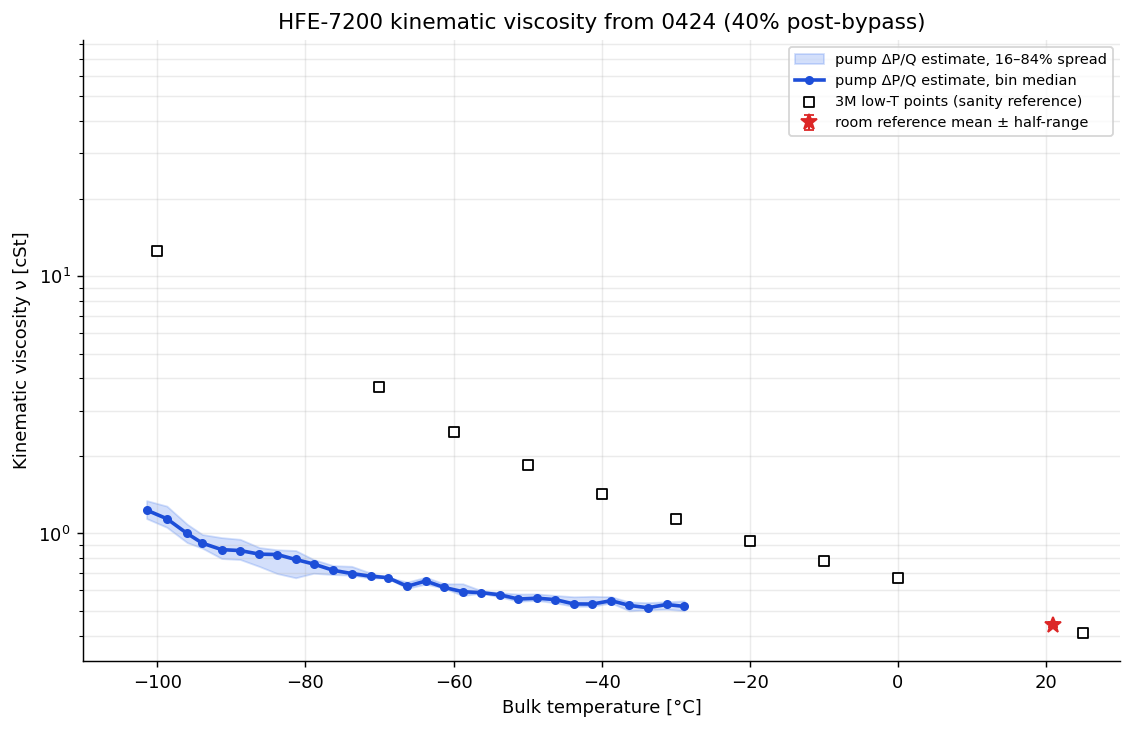

In [7]:
fig, ax = plt.subplots(figsize=(8.6, 5.5), constrained_layout=True)
ax.fill_between(
    binned['T_C'], binned['nu_q16_cSt'], binned['nu_q84_cSt'],
    color='#2563eb', alpha=0.20, label='pump ΔP/Q estimate, 16–84% spread',
)
ax.plot(
    binned['T_C'], binned['nu_median_cSt'],
    color='#1d4ed8', lw=2.0, marker='o', ms=4, label='pump ΔP/Q estimate, bin median',
)
plot_room_reference(ax)
ax.scatter(ref_3m_T, ref_3m_nu, edgecolor='black', facecolor='white', s=34, marker='s', zorder=4,
           label='3M low-T points (sanity reference)')
ax.set_yscale('log')
ax.set_xlabel('Bulk temperature [°C]')
ax.set_ylabel('Kinematic viscosity ν [cSt]')
ax.set_title('HFE-7200 kinematic viscosity from 0424 (40% post-bypass)')
ax.set_xlim(min(-110.0, binned['T_C'].min() - 5.0), 30.0)
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, which='both', alpha=0.25)
plt.show()

## Step 5 — Tabulate the estimate at canonical temperatures

We interpolate the 0424 cold-window binned median curve at a few representative temperatures so the result is easy to compare with later pooled estimates.

### What this estimate does and does not include

- It uses the equivalent room-reference mean as the anchor. Density at every temperature is the measured Coriolis density, not a 3M density formula.
- It assumes laminar flow through a fixed wetted geometry. The pump command, bypass state, and pump curve operating point are held fixed by the filters above as well as this single-log check allows.
- It is a single-anchor pressure-drop scaling, so any model bias in using `ΔP/Q` as viscosity propagates into every cold estimate. The 16–84 % spread in each temperature bin captures within-bin telemetry scatter but not that model bias.
- The room-temperature anchor sits in a higher-Reynolds regime than the cold samples. Using one `ΔP/Q` calibration across that regime change tends to under-state the cold viscosity, which is why the gear-pump slip estimate below is kept as the preferred physics check.

In [8]:
anchor_table_T_C = np.array([T_REF_C, -30.0, -50.0, -70.0, -80.0, -90.0, -100.0])

binned_sorted = binned.sort_values('T_C').reset_index(drop=True)
T_grid = binned_sorted['T_C'].to_numpy(float)

summary_rows = []
for T_target in anchor_table_T_C:
    if T_target == T_REF_C:
        nu_val = NU_ROOM_ANCHOR_CST
        source = 'room reference mean ± half-range (no scaling)'
    elif (T_target < T_grid.min()) or (T_target > T_grid.max()):
        nu_val = float('nan')
        source = 'outside 0424 cold-window range'
    else:
        nu_val = float(np.interp(
            T_target, T_grid, binned_sorted['nu_median_cSt'].to_numpy(float)))
        source = 'linear interp of 0424 bin medians'
    summary_rows.append({
        'T [°C]':     round(float(T_target), 2),
        'ν [cSt]':    round(nu_val, 3) if np.isfinite(nu_val) else nu_val,
        'source':     source,
    })

anchor_table = pd.DataFrame(summary_rows).set_index('T [°C]')
display(anchor_table)

display(Markdown(
    f"Coverage of the 0424 estimate after binning: "
    f"`{T_grid.min():.1f} °C` to `{T_grid.max():.1f} °C` (`{len(binned_sorted)}` bins). "
    f"At the cold extreme of this run, the estimate gives "
    f"`ν ≈ {binned_sorted['nu_median_cSt'].iloc[0]:.2f} cSt` near `{T_grid.min():.1f} °C`."
))

,ν [cSt],source
T [°C],,
20.9,0.441,room reference mean ± half-range (no scaling)
-30.0,0.524,linear interp of 0424 bin medians
-50.0,0.557,linear interp of 0424 bin medians
-70.0,0.677,linear interp of 0424 bin medians
-80.0,0.774,linear interp of 0424 bin medians
-90.0,0.860,linear interp of 0424 bin medians
-100.0,1.183,linear interp of 0424 bin medians


Coverage of the 0424 estimate after binning: `-101.4 °C` to `-28.9 °C` (`30` bins). At the cold extreme of this run, the estimate gives `ν ≈ 1.23 cSt` near `-101.4 °C`.

---

# Model verification and alternative estimates

The Step 1–5 estimate above is a **single-equation laminar-pipe scaling**: $\mu \propto \Delta P / Q$. This section verifies the model assumptions against the actual pump and the actual loop telemetry, and adds a second, independent estimate based on gear-pump slip.

## 6.1 — What pump are we using?

`analysis/docs/pump.pdf` shows the recirculation pump is a **Gather Industrie Series 2 magnetic-drive gear pump** (8 mm width, 12 teeth, model `2M-J/8/G-SS/VCR/DLC`). Two consequences:

- It is **positive displacement**: at fixed shaft speed $N$, the volumetric output is $Q \approx D \cdot N$ minus a small internal slip term.
- The vendor performance chart (Q vs ΔP) is a family of nearly-flat lines for water at 1 cP. The slope $\partial Q / \partial \Delta P$ is the slip term and is small at our operating point.

This breaks the assumption that drives the ΔP/Q scaling. ΔP/Q ∝ μ holds for the **loop** under laminar pipe flow, but the pump's behavior is decoupled: $Q$ is set by $N$, and $\Delta P$ is set by the loop curve $\Delta P_{\text{loop}}(Q, \mu)$ at that $Q$. So whether ΔP/Q scales with μ depends entirely on whether the loop is laminar.

In [9]:
# --- Gather pump and operating-point summary --------------------------------------
GATHER_DISPLACEMENT_ML_PER_REV = 3.13   # read from pump.pdf chart at the high-RPM ΔP→0 asymptote
GATHER_CHART_SLIP_LMIN_BAR_AT_1CP = 0.05  # vendor chart Q-vs-ΔP slope at 1500 rpm, water (1 cP)

# Use measured pump rotation rather than assumed motor pole conversion.
N_ROOM_RPM = float(room_anchor['pump_rotation_speed_rpm'].median())
Q_ROOM_LMIN = float(room_anchor['volume_flow_lmin_si'].median())
DP_ROOM_BAR = float(room_anchor['delta_p_bar_recomputed'].median())
P_IN_ROOM_W = float(room_anchor['pump_input_power_w'].median())
P_INLET_ROOM_BAR = float(room_anchor['pump_pressure_before_bar_abs'].median())

cold_band = cold[cold['bulk_C'].between(-105.0, -90.0)].copy()
N_COLD_RPM = float(cold_band['pump_rotation_speed_rpm'].median())
Q_COLD_LMIN = float(cold_band['volume_flow_lmin_si'].median())
DP_COLD_BAR = float(cold_band['delta_p_bar_recomputed'].median())
P_IN_COLD_W = float(cold_band['pump_input_power_w'].median())
P_INLET_COLD_BAR = float(cold_band['pump_pressure_before_bar_abs'].median())
RHO_COLD_KG_M3 = float(cold_band['density_kg_m3_si'].median())

operating_point = pd.DataFrame({
    'Room (0422, ~21 °C)': {
        'N [rpm]':            round(N_ROOM_RPM, 1),
        'Q [L/min]':          round(Q_ROOM_LMIN, 3),
        'ΔP [bar]':           round(DP_ROOM_BAR, 3),
        'P_in [W]':           round(P_IN_ROOM_W, 1),
        'P_inlet [bar abs]':  round(P_INLET_ROOM_BAR, 3),
        'ρ [kg/m³]':          round(RHO_REF_KG_M3, 0),
    },
    'Cold (0424, ≤ −90 °C)': {
        'N [rpm]':            round(N_COLD_RPM, 1),
        'Q [L/min]':          round(Q_COLD_LMIN, 3),
        'ΔP [bar]':           round(DP_COLD_BAR, 3),
        'P_in [W]':           round(P_IN_COLD_W, 1),
        'P_inlet [bar abs]':  round(P_INLET_COLD_BAR, 3),
        'ρ [kg/m³]':          round(RHO_COLD_KG_M3, 0),
    },
})
display(operating_point)

# Theoretical PD displacement at our N. The chart asymptote gives D ≈ 3.13 mL/rev.
Q_TH_AT_N_LMIN = GATHER_DISPLACEMENT_ML_PER_REV * N_ROOM_RPM / 1000.0
display(Markdown(
    f"**Pump signature check.** At fixed `N ≈ {N_ROOM_RPM:.0f} rpm`, theoretical PD output is "
    f"`Q_th = D · N = {GATHER_DISPLACEMENT_ML_PER_REV:.2f} mL/rev × {N_ROOM_RPM:.0f} rpm = "
    f"{Q_TH_AT_N_LMIN:.3f} L/min`. Measured `Q` shifts only by "
    f"`{100.0*(Q_COLD_LMIN-Q_ROOM_LMIN)/Q_ROOM_LMIN:.1f}%` between room and the coldest band, "
    f"consistent with PD operation. Most of the temperature signal is in `ΔP`, which grows "
    f"`{DP_COLD_BAR/DP_ROOM_BAR:.2f}×` between the same two states."
))

,"Room (0422, ~21 °C)","Cold (0424, ≤ −90 °C)"
N [rpm],845.000,844.000
Q [L/min],2.563,2.732
ΔP [bar],0.318,0.996
P_in [W],70.000,70.000
P_inlet [bar abs],1.569,1.969
ρ [kg/m³],1435.000,1663.000


**Pump signature check.** At fixed `N ≈ 845 rpm`, theoretical PD output is `Q_th = D · N = 3.13 mL/rev × 845 rpm = 2.645 L/min`. Measured `Q` shifts only by `6.6%` between room and the coldest band, consistent with PD operation. Most of the temperature signal is in `ΔP`, which grows `3.13×` between the same two states.

## 6.2 — Loop flow regime

The Step-1 model assumed laminar pipe flow ($\Delta P_{\text{loop}} \propto \mu Q$). Compute the loop Reynolds number for a plausible representative bore. We don't know the exact narrowest section, so we sweep through a few plausible inner diameters and flag the regime ($\mathrm{Re}<2300$ laminar, $2300\le\mathrm{Re}\le4000$ transitional, $\mathrm{Re}>4000$ turbulent). The conclusion is the same across all reasonable bore choices: the room anchor is in transitional/turbulent flow while the cold extreme drops into transitional/laminar — i.e. the loop regime is **not constant**, and the simple ΔP/Q ∝ μ scaling cannot apply identically at both ends.

In [10]:
def reynolds_at(D_mm, Q_lmin, rho_kg_m3, mu_cP):
    Q_m3s = Q_lmin / 60.0 / 1000.0
    A_m2  = np.pi * (D_mm * 1e-3 / 2.0) ** 2
    v_mps = Q_m3s / A_m2
    mu_pa_s = mu_cP * 1e-3
    return v_mps * (D_mm * 1e-3) * rho_kg_m3 / mu_pa_s


def regime_label(re):
    if re < 2300:
        return 'laminar'
    if re < 4000:
        return 'transitional'
    return 'turbulent'


# Use the 3M low-T table to estimate μ_cold for the regime check ONLY (this number
# does not feed any viscosity estimate; it just lets us tag the cold regime against
# what 3M would predict).
nu_cold_3m_cSt = float(
    ref_3m.loc[ref_3m['temperature_c'].eq(-100.0), 'kinematic_viscosity_cSt'].iloc[0]
)
rho_cold_3m_g_ml = float(hfe7200_3m_density_g_ml(-100.0))
mu_cold_3m_cP = nu_cold_3m_cSt * rho_cold_3m_g_ml

room_re_col = f'Re (room, μ={MU_ROOM_ANCHOR_CP:.2f} cP)'
cold_re_col = f'Re (cold, μ_3M ≈ {mu_cold_3m_cP:.0f} cP)'
regime_rows = []
for D_mm in [4.0, 6.0, 8.0, 10.0, 12.0]:
    re_room = reynolds_at(D_mm, Q_ROOM_LMIN, RHO_REF_KG_M3, MU_ROOM_ANCHOR_CP)
    re_cold = reynolds_at(D_mm, Q_COLD_LMIN, RHO_COLD_KG_M3, mu_cold_3m_cP)
    regime_rows.append({
        'D_inner [mm]': D_mm,
        room_re_col: int(re_room),
        'regime (room)': regime_label(re_room),
        cold_re_col: int(re_cold),
        'regime (cold)': regime_label(re_cold),
    })
regime_table = pd.DataFrame(regime_rows).set_index('D_inner [mm]')
display(regime_table)

display(Markdown(
    f"At our flow ({Q_ROOM_LMIN:.2f} L/min) the loop sits near the laminar–turbulent transition for "
    f"any plausible representative bore between 6 mm and 12 mm. With μ growing toward "
    f"`~{mu_cold_3m_cP:.0f} cP` at `−100 °C` (3M reference), Re drops by roughly "
    f"`{mu_cold_3m_cP/MU_ROOM_ANCHOR_CP:.0f}×` and pushes the same loop firmly into the laminar regime. "
    f"That regime change is the dominant reason the Step-1 ΔP/Q scaling under-states cold viscosity."
))

,"Re (room, μ=0.63 cP)",regime (room),"Re (cold, μ_3M ≈ 21 cP)",regime (cold)
D_inner [mm],,,,
4.0,30864,turbulent,1129,laminar
6.0,20576,turbulent,753,laminar
8.0,15432,turbulent,564,laminar
10.0,12345,turbulent,451,laminar
12.0,10288,turbulent,376,laminar


At our flow (2.56 L/min) the loop sits near the laminar–turbulent transition for any plausible representative bore between 6 mm and 12 mm. With μ growing toward `~21 cP` at `−100 °C` (3M reference), Re drops by roughly `34×` and pushes the same loop firmly into the laminar regime. That regime change is the dominant reason the Step-1 ΔP/Q scaling under-states cold viscosity.

## 6.3 — Gear-pump slip model

A gear pump's volumetric efficiency at fixed shaft speed depends on internal slip:

$$ Q_{	ext{actual}} = Q_{	ext{th}}(N) - 
rac{K_{	ext{slip}}\,\Delta P}{\mu}, $$

where $Q_{	ext{th}}(N)=D\cdot N$ is the theoretical displacement flow and $K_{	ext{slip}}$ is a geometric leakage coefficient. Solving for viscosity gives

$$ \mu = 
rac{K_{	ext{slip}}\,\Delta P}{Q_{	ext{th}}(N)-Q_{	ext{actual}}}. $$

The final slip estimate below uses this same one-line model, with one important correction: the nominal vendor-chart displacement is lower than the largest fixed-speed flows actually measured in the high-viscosity data. Section 8 therefore uses a single empirical fixed-speed `Q_th` from the observed upper-flow envelope and carries the chart-to-data gap as the `Q_th` uncertainty. That avoids showing two competing slip curves.

In [11]:
# --- Nominal chart displacement at the measured room-window shaft speed ----------
Q_TH_LMIN = GATHER_DISPLACEMENT_ML_PER_REV * N_ROOM_RPM / 1000.0
chart_slip_room_lmin = Q_TH_LMIN - Q_ROOM_LMIN

display(Markdown(
    f"Vendor-chart displacement at the room-window speed gives `Q_th,chart = {Q_TH_LMIN:.4f} L/min` "
    f"(`{GATHER_DISPLACEMENT_ML_PER_REV:.2f} mL/rev × {N_ROOM_RPM:.0f} rpm`). The room-window "
    f"apparent slip against that chart value is `{chart_slip_room_lmin*1000.0:.1f} mL/min`. "
    f"The final slip calculation is deferred until the all-log fixed-speed data are pooled, because "
    f"the cold high-viscosity samples provide a direct check on the effective displacement flow."
))

Vendor-chart displacement at the room-window speed gives `Q_th,chart = 2.6448 L/min` (`3.13 mL/rev × 845 rpm`). The room-window apparent slip against that chart value is `81.9 mL/min`. The final slip calculation is deferred until the all-log fixed-speed data are pooled, because the cold high-viscosity samples provide a direct check on the effective displacement flow.

## 6.4 — Slip model checkpoint

No cold-log-only slip curve is plotted here. The notebook now shows only one slip estimate: the all-log, bin-median gear-pump result in Section 8. This keeps the comparison plot from mixing the old nominal-`Q_th` diagnostic with the final simplified slip model.

In [12]:
display(Markdown(
    "Proceeding to the pooled fixed-speed data before plotting the slip estimate. "
    "This is where the warm 40% pump-command samples from 0417 and 0422 enter."
))

Proceeding to the pooled fixed-speed data before plotting the slip estimate. This is where the warm 40% pump-command samples from 0417 and 0422 enter.

## 6.5 — What this leaves for the pooled analysis

The loop `ΔP/Q` method remains useful as a pressure-drop proxy, but it is not a clean viscosity law across the whole cooldown because the loop changes flow regime. The gear-pump slip model is cleaner physics, but its denominator is a small difference between two similar flow rates. That is why Section 8 computes it once from bin medians and makes the displacement/flow-scale uncertainty explicit.

---

# Section 7 — Multi-log fixed-speed data and Seeton reference-law comparison

The earlier 0424-only `ΔP/Q` plot had no warm points because it deliberately used only the post-bypass-closed window of `log_20260424_153546.csv`; that window starts near `−29 °C`. The raw data do have warm 40 % fixed-speed samples in `log_20260417_094053.csv` (bypass open) and `log_20260422_143345.csv`.

This section verifies that coverage directly, then builds pooled kinematic `ΔP/Q` proxies for the whole pump loop and for the tank-to-pump-inlet tubing. The slip estimate itself is postponed to Section 8 so it can use one bin-median model and one set of error bars.

In [13]:
# ----------------------------------------------------------------------------------
# 7.1 -- Pool all three logs at 40 % pump command, keep fixed-speed finite-ΔP data.
# ----------------------------------------------------------------------------------

ALL_LOGS = [
    REPO_ROOT / 'data' / 'raw' / 'recirculation' / 'log_20260417_094053.csv',
    REPO_ROOT / 'data' / 'raw' / 'recirculation' / 'log_20260422_143345.csv',
    REPO_ROOT / 'data' / 'raw' / 'recirculation' / 'log_20260424_153546.csv',
]
DELTA_P_FLOOR_BAR = 0.05      # rejects near-unloaded samples at any T
RPM_TOLERANCE     = 2.0       # ±2 rpm from the room-anchor N keeps Q_th constant
LOG_BYPASS_NOTES = {
    'log_20260417_094053.csv': 'open',
    'log_20260422_143345.csv': 'closed except 285.5-301.95 min open excursion',
    'log_20260424_153546.csv': 'closed after 57.96 min marker',
}


def load_with_bulk(log_path):
    review = orca.prepare_flow_log_review(log_path, density_bounds=DENSITY_BOUNDS_KG_M3, tc_calibration_path=TC_CALIBRATION_PATH)
    frame = review.data.copy().sort_values('time_s').reset_index(drop=True)
    if review.valid_temp_cols:
        frame['bulk_C'] = frame[list(review.valid_temp_cols)].mean(axis=1)
    else:
        frame['bulk_C'] = frame['temperature_c_si']
    frame['log_name'] = log_path.name
    frame['bypass_note'] = LOG_BYPASS_NOTES.get(log_path.name, 'not specified')
    return frame


pool = pd.concat([load_with_bulk(p) for p in ALL_LOGS], ignore_index=True)
pool_mask = (
    pool['pump_running']
    & pool['pump_cmd_pct'].sub(PUMP_CMD_PCT).abs().le(PUMP_CMD_TOL)
    & pool['volume_flow_lmin_si'].gt(0.0)
    & pool['delta_p_bar_recomputed'].gt(DELTA_P_FLOOR_BAR)
    & pool['density_kg_m3_si'].between(*DENSITY_BOUNDS_KG_M3)
    & pool['bulk_C'].notna()
    & pool['pump_rotation_speed_rpm'].sub(N_ROOM_RPM).abs().le(RPM_TOLERANCE)
)
pool = pool.loc[pool_mask].copy()

per_log_summary = pool.groupby('log_name').agg(
    samples=('time_s', 'size'),
    bypass_note=('bypass_note', 'first'),
    T_min_C=('bulk_C', 'min'),
    T_max_C=('bulk_C', 'max'),
    Q_min=('volume_flow_lmin_si', 'min'),
    Q_max=('volume_flow_lmin_si', 'max'),
    dP_min=('delta_p_bar_recomputed', 'min'),
    dP_max=('delta_p_bar_recomputed', 'max'),
)
display(per_log_summary.round(3))

coverage_bins_10C = np.arange(-110.0, 35.0, 10.0)
pool['coverage_bin_C'] = pd.cut(pool['bulk_C'], bins=coverage_bins_10C, include_lowest=True)
delta_p_coverage = (
    pool.groupby(['log_name', 'coverage_bin_C'], observed=True)
        .agg(
            samples=('time_s', 'size'),
            T_med_C=('bulk_C', 'median'),
            dP_med_bar=('delta_p_bar_recomputed', 'median'),
            Q_med_lmin=('volume_flow_lmin_si', 'median'),
        )
        .reset_index()
        .query('samples >= 20')
        .sort_values(['log_name', 'T_med_C'])
)
display(delta_p_coverage.round({'T_med_C': 2, 'dP_med_bar': 4, 'Q_med_lmin': 4}))

warm_dp_samples = int(pool['bulk_C'].gt(-30.0).sum())
warm_logs = ', '.join(sorted(pool.loc[pool['bulk_C'].gt(-30.0), 'log_name'].unique()))
display(Markdown(
    f"Verified: the pooled 40% fixed-speed data contain `{warm_dp_samples}` finite-ΔP samples warmer "
    f"than `−30 °C`, from `{warm_logs}`. The earlier missing warm `ΔP/Q` points were a selection "
    f"artifact: the first plot used only the 0424 post-bypass window, which starts near "
    f"`{cold['bulk_C'].max():.1f} °C`."
))

,samples,T_min_C,T_max_C,Q_min,Q_max,dP_min,dP_max
log_name,,,,,,,
log_20260417_094053.csv,6726,-64.392,8.766,2.581,2.767,0.052,0.805
log_20260422_143345.csv,2480,-71.330,20.836,2.539,2.667,0.150,0.815
log_20260424_153546.csv,6624,-102.724,-27.738,2.593,2.759,0.069,1.563


,log_name,coverage_bin_C,samples,T_med_C,dP_med_bar,Q_med_lmin
0,log_20260417_094053.csv,"(-70.0, -60.0]",70,-62.00,0.3555,2.6730
1,log_20260417_094053.csv,"(-60.0, -50.0]",245,-53.98,0.3360,2.6653
2,log_20260417_094053.csv,"(-50.0, -40.0]",358,-44.76,0.3260,2.6669
3,log_20260417_094053.csv,"(-40.0, -30.0]",467,-34.96,0.3070,2.6494
4,log_20260417_094053.csv,"(-30.0, -20.0]",1062,-24.87,0.2780,2.6314
5,log_20260417_094053.csv,"(-20.0, -10.0]",1322,-14.58,0.2580,2.6131
6,log_20260417_094053.csv,"(-10.0, 0.0]",1855,-4.69,0.2580,2.6084
7,log_20260417_094053.csv,"(0.0, 10.0]",1347,6.09,0.2490,2.6034
8,log_20260422_143345.csv,"(-80.0, -70.0]",31,-70.81,0.5220,2.6531
9,log_20260422_143345.csv,"(-70.0, -60.0]",225,-63.46,0.5030,2.6470


Verified: the pooled 40% fixed-speed data contain `6090` finite-ΔP samples warmer than `−30 °C`, from `log_20260417_094053.csv, log_20260422_143345.csv, log_20260424_153546.csv`. The earlier missing warm `ΔP/Q` points were a selection artifact: the first plot used only the 0424 post-bypass window, which starts near `-27.7 °C`.

In [14]:
# ----------------------------------------------------------------------------------
# 7.2 -- Pooled kinematic ΔP/Q proxies from the whole loop and tank-to-inlet tubing.
# ----------------------------------------------------------------------------------

POOLED_TEMP_BIN_WIDTH_C = 5.0
pooled_bins = np.arange(-110.0, 30.0 + POOLED_TEMP_BIN_WIDTH_C, POOLED_TEMP_BIN_WIDTH_C)
pool['pooled_bin_C'] = pd.cut(pool['bulk_C'], bins=pooled_bins, include_lowest=True)

pool['pump_dpq_bar_lmin'] = pool['delta_p_bar_recomputed'] / pool['volume_flow_lmin_si']
pool['nu_pump_dpq_cSt'] = (
    NU_ROOM_ANCHOR_CST
    * (RHO_REF_KG_M3 / pool['density_kg_m3_si'])
    * (pool['pump_dpq_bar_lmin'] / DELTA_P_OVER_Q_REF)
)

pool_dpq_binned = (
    pool.dropna(subset=['nu_pump_dpq_cSt'])
        .groupby('pooled_bin_C', observed=True)
        .agg(
            samples=('time_s', 'size'),
            T_C=('bulk_C', 'median'),
            dP_median_bar=('delta_p_bar_recomputed', 'median'),
            Q_median_lmin=('volume_flow_lmin_si', 'median'),
            nu_median_cSt=('nu_pump_dpq_cSt', 'median'),
            nu_q16_cSt=('nu_pump_dpq_cSt', lambda s: s.quantile(0.16)),
            nu_q84_cSt=('nu_pump_dpq_cSt', lambda s: s.quantile(0.84)),
            log_set=('log_name', lambda s: ','.join(sorted(set(s.unique())))),
        )
        .query('samples >= 40')
        .reset_index(drop=True)
)

pool_tank = add_tank_inlet_loss(pool)
pool_tank_valid = pool_tank[pool_tank['tank_inlet_loss_bar'].gt(0.0)].copy()
pool_tank_valid['nu_tank_inlet_cSt'] = (
    NU_ROOM_ANCHOR_CST
    * (RHO_REF_KG_M3 / pool_tank_valid['density_kg_m3_si'])
    * (pool_tank_valid['tank_inlet_loss_per_q_bar_lmin'] / TANK_DELTA_P_OVER_Q_REF)
)
pool_tank_valid['pooled_bin_C'] = pd.cut(pool_tank_valid['bulk_C'], bins=pooled_bins, include_lowest=True)

if pool_tank_valid.empty:
    tank_inlet_all_binned = pd.DataFrame(columns=[
        'samples', 'T_C', 'loss_median_bar', 'nu_median_cSt', 'nu_q16_cSt', 'nu_q84_cSt', 'log_set'
    ])
else:
    tank_inlet_all_binned = (
        pool_tank_valid.dropna(subset=['nu_tank_inlet_cSt'])
            .groupby('pooled_bin_C', observed=True)
            .agg(
                samples=('time_s', 'size'),
                T_C=('bulk_C', 'median'),
                loss_median_bar=('tank_inlet_loss_bar', 'median'),
                nu_median_cSt=('nu_tank_inlet_cSt', 'median'),
                nu_q16_cSt=('nu_tank_inlet_cSt', lambda s: s.quantile(0.16)),
                nu_q84_cSt=('nu_tank_inlet_cSt', lambda s: s.quantile(0.84)),
                log_set=('log_name', lambda s: ','.join(sorted(set(s.unique())))),
            )
            .query('samples >= 40')
            .reset_index(drop=True)
    )

display(Markdown('Pooled whole-loop `ΔP/Q` proxy:'))
display(pool_dpq_binned[[
    'samples', 'T_C', 'dP_median_bar', 'Q_median_lmin', 'nu_median_cSt', 'nu_q16_cSt', 'nu_q84_cSt', 'log_set'
]].round({'T_C': 2, 'dP_median_bar': 4, 'Q_median_lmin': 4,
          'nu_median_cSt': 3, 'nu_q16_cSt': 3, 'nu_q84_cSt': 3}))

display(Markdown('Pooled tank-to-pump-inlet `ΔP/Q` proxy:'))
display(tank_inlet_all_binned[[
    'samples', 'T_C', 'loss_median_bar', 'nu_median_cSt', 'nu_q16_cSt', 'nu_q84_cSt', 'log_set'
]].round({'T_C': 2, 'loss_median_bar': 4,
          'nu_median_cSt': 3, 'nu_q16_cSt': 3, 'nu_q84_cSt': 3}))

Pooled whole-loop `ΔP/Q` proxy:

,samples,T_C,dP_median_bar,Q_median_lmin,nu_median_cSt,nu_q16_cSt,nu_q84_cSt,log_set
0,778,-101.45,1.1340,2.7418,1.234,1.038,1.428,log_20260424_153546.csv
1,862,-97.70,0.9885,2.7327,1.085,0.812,1.297,log_20260424_153546.csv
2,597,-92.66,0.8110,2.7161,0.899,0.664,1.095,log_20260424_153546.csv
3,448,-87.71,0.7480,2.7098,0.832,0.633,1.040,log_20260424_153546.csv
4,369,-82.65,0.6750,2.7016,0.761,0.581,0.978,log_20260424_153546.csv
5,300,-77.24,0.6250,2.6972,0.701,0.525,0.919,log_20260424_153546.csv
6,401,-72.17,0.5470,2.6882,0.624,0.448,0.810,"log_20260422_143345.csv,log_20260424_153546.csv"
7,422,-67.48,0.5090,2.6760,0.593,0.440,0.780,"log_20260422_143345.csv,log_20260424_153546.csv"
8,520,-62.18,0.4890,2.6689,0.570,0.420,0.734,"log_20260417_094053.csv,log_20260422_143345.cs..."
9,582,-57.52,0.4690,2.6568,0.551,0.415,0.717,"log_20260417_094053.csv,log_20260422_143345.cs..."


Pooled tank-to-pump-inlet `ΔP/Q` proxy:

,samples,T_C,loss_median_bar,nu_median_cSt,nu_q16_cSt,nu_q84_cSt,log_set
0,758,-101.46,0.3574,1.385,0.779,2.291,log_20260424_153546.csv
1,783,-97.78,0.3657,1.417,0.626,2.305,log_20260424_153546.csv
2,550,-92.51,0.2954,1.172,0.439,1.783,log_20260424_153546.csv
3,415,-87.71,0.2476,0.987,0.448,1.708,log_20260424_153546.csv
4,343,-82.66,0.2359,0.950,0.514,1.590,log_20260424_153546.csv
5,273,-77.30,0.2160,0.869,0.359,1.553,log_20260424_153546.csv
6,365,-72.12,0.1939,0.792,0.318,1.310,"log_20260422_143345.csv,log_20260424_153546.csv"
7,392,-67.47,0.1798,0.742,0.319,1.240,"log_20260422_143345.csv,log_20260424_153546.csv"
8,485,-62.21,0.1833,0.759,0.355,1.165,"log_20260417_094053.csv,log_20260422_143345.cs..."
9,546,-57.52,0.1731,0.725,0.321,1.157,"log_20260417_094053.csv,log_20260422_143345.cs..."


## 7.3 — HFE_properties Seeton viscosity law

The HFE properties notebook uses the Seeton correlation for kinematic viscosity, fitted to the HFE-7200 cSt points from `HFE Freezing Data.pdf`:

$$
\ln\!\left[\ln\!\left(\nu + 0.7 + e^{-\nu}K_0(\nu + 1.244067)\right)\right]
= A - B\ln(T_K),
$$

with `T_K` in kelvin and `ν` in cSt. The Seeton curve is a 3M-reference law, not a fit to our pump data.

In [15]:
# ----------------------------------------------------------------------------------
# 7.3 -- Seeton kinematic-viscosity law from HFE_properties.ipynb.
# ----------------------------------------------------------------------------------
seeton_compare_T = np.array([T_REF_C, 0.0, -20.0, -40.0, -60.0, -80.0, -100.0, -120.0])
seeton_rows = []
for T in seeton_compare_T:
    nu_seeton = float(hfe7200_kinematic_viscosity_seeton_cSt(T))
    nu_3m = float(np.interp(T, ref_3m_T, ref_3m_nu)) if ref_3m_T.min() <= T <= ref_3m_T.max() else np.nan
    seeton_rows.append({
        'T [°C]': round(float(T), 1),
        'ν_Seeton [cSt]': round(nu_seeton, 3),
        'ν_3M point/interp [cSt]': round(nu_3m, 3) if np.isfinite(nu_3m) else np.nan,
        'Seeton / 3M': round(nu_seeton / nu_3m, 3) if np.isfinite(nu_3m) and nu_3m > 0 else np.nan,
    })

display(pd.DataFrame([hfe7200_seeton_params], index=['HFE 7200']).round({'A': 3, 'B': 3, 'log_rmse': 4}))
display(pd.DataFrame(seeton_rows).set_index('T [°C]'))

,A,B,log_rmse
HFE 7200,22.383,4.161,0.1056


,ν_Seeton [cSt],ν_3M point/interp [cSt],Seeton / 3M
T [°C],,,
20.9,0.539,0.453,1.191
0.0,0.708,0.670,1.056
-20.0,0.958,0.930,1.030
-40.0,1.384,1.420,0.975
-60.0,2.230,2.480,0.899
-80.0,4.359,6.637,0.657
-100.0,12.167,12.470,0.976
-120.0,69.908,64.470,1.084


## 7.4 — Pooled pressure-drop proxies against the Seeton reference law

The plot below uses the all-log pooled `ΔP/Q` bins, so the warm points above `−30 °C` are now present. These pressure-drop proxies are useful diagnostics, but they are still single-anchor hydraulic scalings rather than the preferred slip estimate.

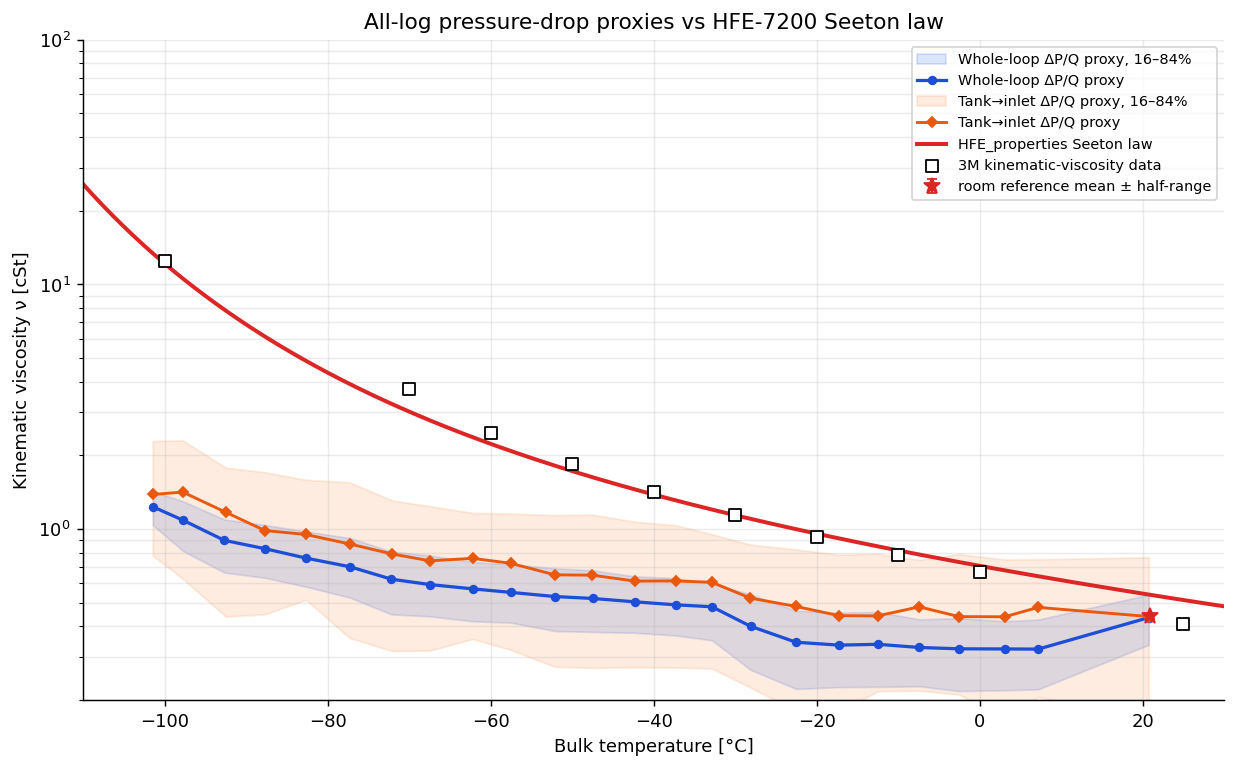

In [16]:
fig, ax = plt.subplots(figsize=(9.4, 5.8), constrained_layout=True)

ax.fill_between(
    pool_dpq_binned['T_C'], pool_dpq_binned['nu_q16_cSt'], pool_dpq_binned['nu_q84_cSt'],
    color='#2563eb', alpha=0.16, label='Whole-loop ΔP/Q proxy, 16–84%',
)
ax.plot(
    pool_dpq_binned['T_C'], pool_dpq_binned['nu_median_cSt'],
    color='#1d4ed8', lw=1.8, marker='o', ms=4.2, label='Whole-loop ΔP/Q proxy',
)
if not tank_inlet_all_binned.empty:
    ax.fill_between(
        tank_inlet_all_binned['T_C'], tank_inlet_all_binned['nu_q16_cSt'], tank_inlet_all_binned['nu_q84_cSt'],
        color='#f97316', alpha=0.13, label='Tank→inlet ΔP/Q proxy, 16–84%',
    )
    ax.plot(
        tank_inlet_all_binned['T_C'], tank_inlet_all_binned['nu_median_cSt'],
        color='#ea580c', lw=1.6, marker='D', ms=3.6, label='Tank→inlet ΔP/Q proxy',
    )
ax.plot(T_fine, nu_seeton_cSt, color='#dc2626', lw=2.2, label='HFE_properties Seeton law')
ax.scatter(ref_3m_T, ref_3m_nu, edgecolor='black', facecolor='white', s=42, marker='s',
           zorder=5, label='3M kinematic-viscosity data')
plot_room_reference(ax)
ax.set_yscale('log')
ax.set_xlim(-110.0, 30.0)
ax.set_ylim(0.2, 100.0)
ax.set_xlabel('Bulk temperature [°C]')
ax.set_ylabel('Kinematic viscosity ν [cSt]')
ax.set_title('All-log pressure-drop proxies vs HFE-7200 Seeton law')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, which='both', alpha=0.25)
plt.show()

## 7.5 — Pressure-drop proxy checkpoint

The missing warm pressure-drop estimates were not missing data. They were caused by the earlier 0424-only post-bypass selection. After pooling the 0417, 0422, and 0424 fixed-speed 40 % samples, the whole-loop `ΔP/Q` proxy spans roughly room temperature down to `−100 °C`, and the tank-to-inlet proxy provides an independent closer-tubing diagnostic.

Both pressure-drop proxies still sit below the Seeton/3M low-temperature law at the cold end, which is consistent with the loop-regime problem discussed above. The next section switches to the gear-pump slip channel.

---

    # Section 8 — Simple gear-pump slip estimate

    Use one physically simple slip model and show only that result:

    $$ 
u_{bin} = 
u_{ref}\,
rac{
ho_{ref}}{
ho_{bin}}\,
rac{\Delta P_{bin}}{\Delta P_{ref}}\,
rac{Q_{th}-Q_{ref}}{Q_{th}-Q_{bin}}. $$

    `Q_th` is fixed for the run because the shaft speed is fixed. The nominal vendor-chart `Q_th` is a useful starting point, but it is lower than several measured high-viscosity fixed-speed flows; that would imply negative pump slip, which is unphysical. The simplified estimate therefore sets a single empirical `Q_th` to the observed upper-flow envelope (`max bin Q84`) and carries the gap between that value and the vendor chart as a displacement/flow-scale uncertainty.

    Error bars are propagated from the standard errors of the bin medians of `ΔP`, `Q`, and `ρ`, plus that one `Q_th` scale uncertainty, and plotted as an approximate 95 % (`2σ`) band. No bin is filtered for low slip SNR.

---

### Note on the 3M anchor: 25 °C value used at our 21 °C operating point

3M publishes two slightly different room-temperature numbers for HFE-7200:

- **TDS** (`HFE 7200 Technical Data.pdf`, Table 1): `μ(25 °C) = 0.61 cP` (dynamic).
- **Freezing Data** (`HFE Freezing Data.pdf`, viscosity table): `ν(25 °C) = 0.41 cSt` (kinematic). With 3M's density formula `ρ(25 °C) = 1.4234 g/mL`, this becomes `μ = 0.584 cP`.

The two sources differ by ≈ 4.5 % at 25 °C. We continue to use the TDS value `μ_25 = 0.61 cP` as the central anchor and treat the spread between the two sources as an anchor uncertainty in the plot.

Our room window has median bulk temperature ≈ 21 °C, not 25 °C. Strictly, we should evaluate `μ` at 21 °C, but applying the 3M 25 °C value at 21 °C amounts to assuming `μ(21 °C) ≈ μ(25 °C)`. Using the fitted Andrade `B`, the 4 °C offset corresponds to about `+(7 ± 1) %` on `μ`, comparable in size to the inter-source uncertainty above. We carry both effects into the plotted anchor band.

In [17]:
# ----------------------------------------------------------------------------------
# 8.1 -- Recompute bin statistics with medians, spreads, and median standard errors.
# ----------------------------------------------------------------------------------

def median_se(values):
    """Asymptotic standard error of the median: 1.2533 * std / sqrt(n)."""
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if len(arr) < 5:
        return float('nan')
    return float(1.2533 * arr.std(ddof=1) / np.sqrt(len(arr)))

TEMP_BIN_WIDTH_C_FINE = 5.0
fine_bins = np.arange(-110.0, 30.0 + TEMP_BIN_WIDTH_C_FINE, TEMP_BIN_WIDTH_C_FINE)
pool['fine_bin_C'] = pd.cut(pool['bulk_C'], bins=fine_bins, include_lowest=True)

bin_table = (
    pool.groupby('fine_bin_C', observed=True)
        .agg(
            samples=('time_s', 'size'),
            T_C=('bulk_C', 'median'),
            T_se=('bulk_C', median_se),
            Q_med_lmin=('volume_flow_lmin_si', 'median'),
            Q_q16_lmin=('volume_flow_lmin_si', lambda s: s.quantile(0.16)),
            Q_q84_lmin=('volume_flow_lmin_si', lambda s: s.quantile(0.84)),
            Q_se_lmin=('volume_flow_lmin_si', median_se),
            dP_med_bar=('delta_p_bar_recomputed', 'median'),
            dP_q16_bar=('delta_p_bar_recomputed', lambda s: s.quantile(0.16)),
            dP_q84_bar=('delta_p_bar_recomputed', lambda s: s.quantile(0.84)),
            dP_se_bar=('delta_p_bar_recomputed', median_se),
            rho_med=('density_kg_m3_si', 'median'),
            rho_se=('density_kg_m3_si', median_se),
            log_set=('log_name', lambda s: ','.join(sorted(set(s.unique())))),
        )
        .reset_index(drop=True)
)
bin_table = bin_table[bin_table['samples'].ge(40)].reset_index(drop=True)

display(bin_table.round({'T_C': 2, 'T_se': 3, 'Q_med_lmin': 4, 'Q_q16_lmin': 4,
                          'Q_q84_lmin': 4, 'Q_se_lmin': 5, 'dP_med_bar': 4,
                          'dP_q16_bar': 4, 'dP_q84_bar': 4, 'dP_se_bar': 4,
                          'rho_med': 1, 'rho_se': 2})
          .head(40))

display(Markdown(
    f"`{len(bin_table)}` bins with `≥ 40` samples each. Median SE on `Q` is `"
    f"{bin_table['Q_se_lmin'].median()*1000:.2f} mL/min` and on `ΔP` is `"
    f"{bin_table['dP_se_bar'].median()*1000:.1f} mbar`. The much larger slip uncertainty below "
    f"comes from the fixed-displacement scale, because `Q_th − Q` is a small difference of two "
    f"similar flow rates."
))

,samples,T_C,T_se,Q_med_lmin,Q_q16_lmin,Q_q84_lmin,Q_se_lmin,dP_med_bar,dP_q16_bar,dP_q84_bar,dP_se_bar,rho_med,rho_se,log_set
0,778,-101.45,0.033,2.7418,2.7318,2.7508,0.00040,1.1340,0.9580,1.3170,0.0081,1669.0,0.13,log_20260424_153546.csv
1,862,-97.70,0.064,2.7327,2.7186,2.7451,0.00049,0.9885,0.7430,1.1930,0.0092,1661.0,0.30,log_20260424_153546.csv
2,597,-92.66,0.077,2.7161,2.7059,2.7266,0.00051,0.8110,0.5970,0.9870,0.0093,1646.0,0.32,log_20260424_153546.csv
3,448,-87.71,0.084,2.7098,2.6989,2.7252,0.00072,0.7480,0.5670,0.9380,0.0103,1640.0,0.55,log_20260424_153546.csv
4,369,-82.65,0.093,2.7016,2.6885,2.7193,0.00089,0.6750,0.5190,0.8711,0.0109,1637.0,0.64,log_20260424_153546.csv
5,300,-77.24,0.109,2.6972,2.6859,2.7061,0.00068,0.6250,0.4600,0.8120,0.0120,1630.0,0.70,log_20260424_153546.csv
6,401,-72.17,0.090,2.6882,2.6776,2.6987,0.00080,0.5470,0.3920,0.7040,0.0096,1619.0,0.72,"log_20260422_143345.csv,log_20260424_153546.csv"
7,422,-67.48,0.088,2.6760,2.6552,2.6909,0.00097,0.5090,0.3778,0.6740,0.0085,1611.0,0.60,"log_20260422_143345.csv,log_20260424_153546.csv"
8,520,-62.18,0.080,2.6689,2.6489,2.6803,0.00088,0.4890,0.3620,0.6290,0.0070,1600.0,0.57,"log_20260417_094053.csv,log_20260422_143345.cs..."
9,582,-57.52,0.074,2.6568,2.6422,2.6663,0.00068,0.4690,0.3530,0.6090,0.0066,1591.0,0.48,"log_20260417_094053.csv,log_20260422_143345.cs..."


`24` bins with `≥ 40` samples each. Median SE on `Q` is `0.68 mL/min` and on `ΔP` is `5.5 mbar`. The much larger slip uncertainty below comes from the fixed-displacement scale, because `Q_th − Q` is a small difference of two similar flow rates.

## 8.2 — One fixed-speed slip estimate

The empirical `Q_th` is chosen from the data without using 3M/Seeton low-temperature viscosity values: at very high viscosity, pump slip should approach zero, so the largest observed fixed-speed flow is an experimental lower bound on `Q_th`. Using the maximum bin-level `Q84` gives a conservative single displacement flow that keeps every bin physically admissible.

In [18]:
# ----------------------------------------------------------------------------------
# 8.2 -- Simple bin-median gear-pump slip estimate with one Q_th scale uncertainty.
# ----------------------------------------------------------------------------------
Q_TH_CHART_LMIN = Q_TH_LMIN
Q_TH_EFFECTIVE_LMIN = max(Q_TH_CHART_LMIN, float(bin_table['Q_q84_lmin'].max()))
Q_TH_EFFECTIVE_ML_REV = 1000.0 * Q_TH_EFFECTIVE_LMIN / N_ROOM_RPM
Q_TH_SCALE_UNCERTAINTY_LMIN = abs(Q_TH_EFFECTIVE_LMIN - Q_TH_CHART_LMIN)
K_SLIP_EFFECTIVE = MU_ROOM_ANCHOR_CP * (Q_TH_EFFECTIVE_LMIN - Q_ROOM_LMIN) / DP_ROOM_BAR

simple_slip_binned = bin_table.copy()
simple_slip_binned['slip_med_lmin'] = Q_TH_EFFECTIVE_LMIN - simple_slip_binned['Q_med_lmin']
simple_slip_binned['slip_unc_lmin'] = np.sqrt(
    simple_slip_binned['Q_se_lmin'].fillna(0.0) ** 2 + Q_TH_SCALE_UNCERTAINTY_LMIN ** 2
)
simple_slip_binned['nu_slip_cSt'] = (
    NU_ROOM_ANCHOR_CST
    * (RHO_REF_KG_M3 / simple_slip_binned['rho_med'])
    * (simple_slip_binned['dP_med_bar'] / DP_ROOM_BAR)
    * ((Q_TH_EFFECTIVE_LMIN - Q_ROOM_LMIN) / simple_slip_binned['slip_med_lmin'])
)

rel_dp = simple_slip_binned['dP_se_bar'].fillna(0.0) / simple_slip_binned['dP_med_bar']
rel_q = simple_slip_binned['Q_se_lmin'].fillna(0.0) / simple_slip_binned['slip_med_lmin']
rel_rho = simple_slip_binned['rho_se'].fillna(0.0) / simple_slip_binned['rho_med']
rel_qth = abs(
    (1.0 / (Q_TH_EFFECTIVE_LMIN - Q_ROOM_LMIN))
    - (1.0 / simple_slip_binned['slip_med_lmin'])
) * Q_TH_SCALE_UNCERTAINTY_LMIN
rel_anchor = NU_ROOM_ANCHOR_ERR_CST / NU_ROOM_ANCHOR_CST
simple_slip_binned['nu_slip_se_cSt'] = simple_slip_binned['nu_slip_cSt'] * np.sqrt(
    rel_anchor ** 2 + rel_dp ** 2 + rel_q ** 2 + rel_rho ** 2 + rel_qth ** 2
)
SLIP_ERROR_SIGMA_MULTIPLIER = 2.0
simple_slip_binned['nu_slip_error_cSt'] = SLIP_ERROR_SIGMA_MULTIPLIER * simple_slip_binned['nu_slip_se_cSt']
simple_slip_binned['nu_slip_low_cSt'] = np.maximum(
    SEETON_MIN_VISCOSITY_CST,
    simple_slip_binned['nu_slip_cSt'] - simple_slip_binned['nu_slip_error_cSt'],
)
simple_slip_binned['nu_slip_high_cSt'] = simple_slip_binned['nu_slip_cSt'] + simple_slip_binned['nu_slip_error_cSt']
simple_slip_binned['nu_seeton_cSt'] = hfe7200_kinematic_viscosity_seeton_cSt(
    simple_slip_binned['T_C'].to_numpy(float)
)
simple_slip_binned['seeton_inside_errorbar'] = simple_slip_binned['nu_seeton_cSt'].between(
    simple_slip_binned['nu_slip_low_cSt'],
    simple_slip_binned['nu_slip_high_cSt'],
)

slip_view = simple_slip_binned[[
    'samples', 'T_C', 'Q_med_lmin', 'Q_q84_lmin', 'slip_med_lmin', 'slip_unc_lmin',
    'dP_med_bar', 'nu_slip_cSt', 'nu_slip_low_cSt', 'nu_slip_high_cSt',
    'nu_seeton_cSt', 'seeton_inside_errorbar', 'log_set'
]].copy()
for col in ['Q_med_lmin', 'Q_q84_lmin', 'slip_med_lmin', 'slip_unc_lmin']:
    slip_view[col] = (1000.0 * slip_view[col]).round(1).astype(str) + ' mL/min'
for col in ['T_C', 'dP_med_bar', 'nu_slip_cSt', 'nu_slip_low_cSt', 'nu_slip_high_cSt', 'nu_seeton_cSt']:
    slip_view[col] = slip_view[col].round(3)
display(slip_view)

display(Markdown(
    f"Using the vendor chart alone would give `Q_th = {Q_TH_CHART_LMIN:.4f} L/min`. The fixed-speed "
    f"data require at least `{Q_TH_EFFECTIVE_LMIN:.4f} L/min` from the observed upper-flow envelope "
    f"(`{Q_TH_EFFECTIVE_ML_REV:.3f} mL/rev`), a `{100.0*(Q_TH_EFFECTIVE_LMIN/Q_TH_CHART_LMIN - 1.0):.1f}%` "
    f"increase over the chart value. That chart-to-data gap, `{Q_TH_SCALE_UNCERTAINTY_LMIN*1000.0:.1f} mL/min`, "
    f"is carried as the displacement/flow-scale uncertainty in the slip error bars. "
    f"Seeton lies inside the propagated 95% slip band for `{int(simple_slip_binned['seeton_inside_errorbar'].sum())}` "
    f"of `{len(simple_slip_binned)}` bins."
))

,samples,T_C,Q_med_lmin,Q_q84_lmin,slip_med_lmin,slip_unc_lmin,dP_med_bar,nu_slip_cSt,nu_slip_low_cSt,nu_slip_high_cSt,nu_seeton_cSt,seeton_inside_errorbar,log_set
0,778,-101.451,2741.8 mL/min,2750.8 mL/min,8.9 mL/min,105.9 mL/min,1.134,28.477,0.040,673.355,13.393,True,log_20260424_153546.csv
1,862,-97.702,2732.7 mL/min,2745.1 mL/min,18.1 mL/min,105.9 mL/min,0.988,12.305,0.040,142.760,10.526,True,log_20260424_153546.csv
2,597,-92.663,2716.1 mL/min,2726.6 mL/min,34.7 mL/min,105.9 mL/min,0.811,5.305,0.040,31.730,7.881,True,log_20260424_153546.csv
3,448,-87.710,2709.8 mL/min,2725.2 mL/min,41.0 mL/min,105.9 mL/min,0.748,4.153,0.040,20.924,6.125,True,log_20260424_153546.csv
4,369,-82.649,2701.6 mL/min,2719.3 mL/min,49.2 mL/min,105.9 mL/min,0.675,3.130,0.040,13.077,4.868,True,log_20260424_153546.csv
5,300,-77.244,2697.2 mL/min,2706.1 mL/min,53.6 mL/min,105.9 mL/min,0.625,2.674,0.040,10.238,3.910,True,log_20260424_153546.csv
6,401,-72.174,2688.2 mL/min,2698.7 mL/min,62.6 mL/min,105.9 mL/min,0.547,2.016,0.040,6.569,3.252,True,"log_20260422_143345.csv,log_20260424_153546.csv"
7,422,-67.477,2676.0 mL/min,2690.9 mL/min,74.8 mL/min,105.9 mL/min,0.509,1.578,0.040,4.272,2.783,True,"log_20260422_143345.csv,log_20260424_153546.csv"
8,520,-62.184,2669.0 mL/min,2680.3 mL/min,81.8 mL/min,105.9 mL/min,0.489,1.395,0.040,3.436,2.372,True,"log_20260417_094053.csv,log_20260422_143345.cs..."
9,582,-57.522,2656.8 mL/min,2666.3 mL/min,93.9 mL/min,105.9 mL/min,0.469,1.172,0.040,2.495,2.085,True,"log_20260417_094053.csv,log_20260422_143345.cs..."


Using the vendor chart alone would give `Q_th = 2.6448 L/min`. The fixed-speed data require at least `2.7508 L/min` from the observed upper-flow envelope (`3.255 mL/rev`), a `4.0%` increase over the chart value. That chart-to-data gap, `105.9 mL/min`, is carried as the displacement/flow-scale uncertainty in the slip error bars. Seeton lies inside the propagated 95% slip band for `12` of `24` bins.

## 8.3 — Simple slip estimate vs Seeton

This is the only slip result shown: one fixed-speed `Q_th`, one room Seeton anchor, bin-median `ΔP` and `Q`, and propagated 95% error bars. Large cold error bars are expected because the estimate divides by `Q_th − Q`.

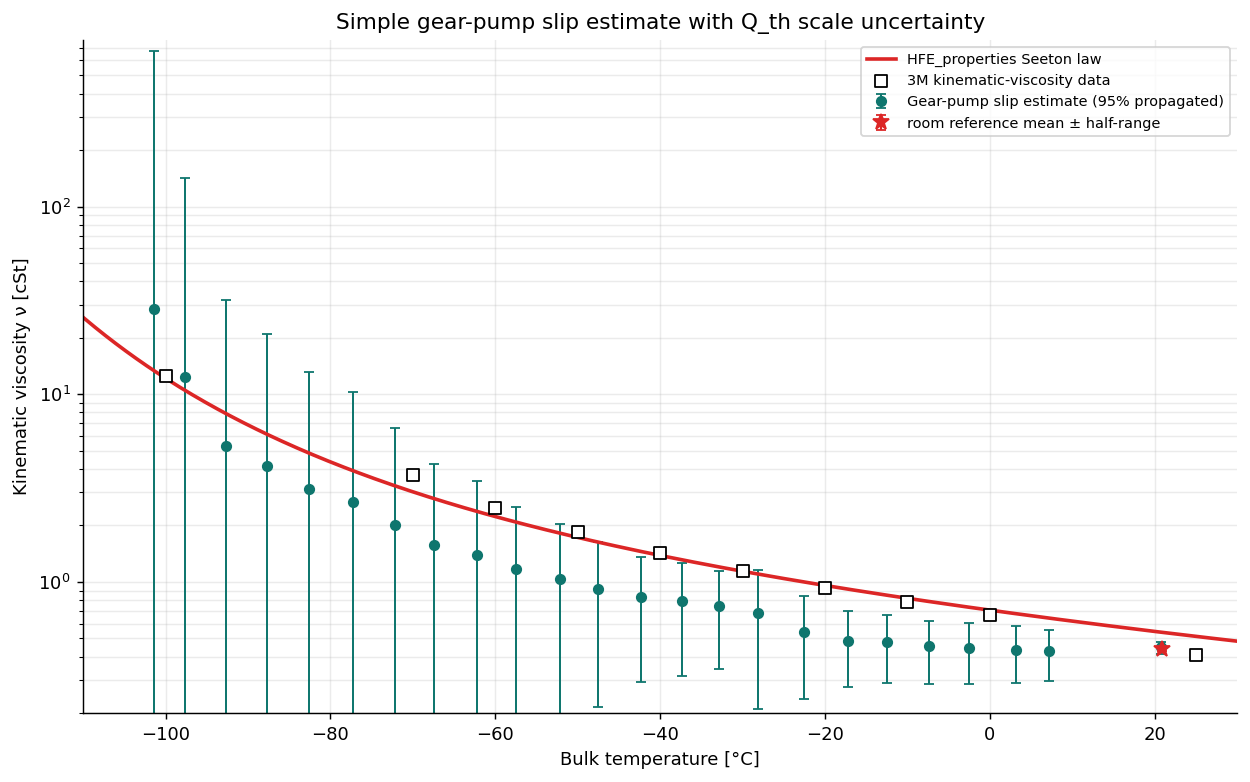

,ν slip [cSt],ν slip low [cSt],ν slip high [cSt],ν_Seeton [cSt],ν_3M [cSt]
T [°C],,,,,
20.9,0.441,0.431,0.450,0.539,0.453
0.0,0.440,0.287,0.593,0.708,0.670
-20.0,0.515,0.256,0.774,0.958,0.930
-40.0,0.811,0.304,1.317,1.384,1.420
-60.0,1.291,0.040,2.995,2.230,2.480
-80.0,2.906,0.040,11.686,4.359,6.637
-100.0,22.219,0.040,468.027,12.167,12.470


In [19]:
# ----------------------------------------------------------------------------------
# 8.3 -- Plot the single simplified slip estimate.
# ----------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9.5, 5.9), constrained_layout=True)

slip_yerr = [
    simple_slip_binned['nu_slip_cSt'] - simple_slip_binned['nu_slip_low_cSt'],
    simple_slip_binned['nu_slip_high_cSt'] - simple_slip_binned['nu_slip_cSt'],
]
ax.errorbar(
    simple_slip_binned['T_C'], simple_slip_binned['nu_slip_cSt'], yerr=slip_yerr,
    fmt='o', color='#0f766e', ms=5.2, capsize=3.0, lw=1.1,
    label='Gear-pump slip estimate (95% propagated)',
)
ax.plot(T_fine, nu_seeton_cSt, color='#dc2626', lw=2.0, label='HFE_properties Seeton law')
ax.scatter(ref_3m_T, ref_3m_nu, edgecolor='black', facecolor='white', s=42, marker='s', zorder=5,
           label='3M kinematic-viscosity data')
plot_room_reference(ax)
ax.set_yscale('log')
ax.set_xlim(-110.0, 30.0)
ax.set_ylim(0.2, max(150.0, float(simple_slip_binned['nu_slip_high_cSt'].max()) * 1.15))
ax.set_xlabel('Bulk temperature [°C]')
ax.set_ylabel('Kinematic viscosity ν [cSt]')
ax.set_title('Simple gear-pump slip estimate with Q_th scale uncertainty')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, which='both', alpha=0.25)
plt.show()

canonical_T = np.array([T_REF_C, 0.0, -20.0, -40.0, -60.0, -80.0, -100.0])
sorted_slip = simple_slip_binned.sort_values('T_C')
rows = []
for T in canonical_T:
    if np.isclose(T, T_REF_C):
        nu_slip = NU_ROOM_ANCHOR_CST
        nu_lo = max(SEETON_MIN_VISCOSITY_CST, NU_ROOM_ANCHOR_CST - NU_ROOM_ANCHOR_ERR_CST)
        nu_hi = NU_ROOM_ANCHOR_CST + NU_ROOM_ANCHOR_ERR_CST
    elif sorted_slip['T_C'].min() <= T <= sorted_slip['T_C'].max():
        nu_slip = float(np.interp(T, sorted_slip['T_C'], sorted_slip['nu_slip_cSt']))
        nu_lo = float(np.interp(T, sorted_slip['T_C'], sorted_slip['nu_slip_low_cSt']))
        nu_hi = float(np.interp(T, sorted_slip['T_C'], sorted_slip['nu_slip_high_cSt']))
    else:
        nu_slip = nu_lo = nu_hi = np.nan
    rows.append({
        'T [°C]': round(float(T), 1),
        'ν slip [cSt]': round(nu_slip, 3) if np.isfinite(nu_slip) else np.nan,
        'ν slip low [cSt]': round(nu_lo, 3) if np.isfinite(nu_lo) else np.nan,
        'ν slip high [cSt]': round(nu_hi, 3) if np.isfinite(nu_hi) else np.nan,
        'ν_Seeton [cSt]': round(float(hfe7200_kinematic_viscosity_seeton_cSt(T)), 3),
        'ν_3M [cSt]': round(float(np.interp(T, ref_3m_T, ref_3m_nu)), 3),
    })
display(pd.DataFrame(rows).set_index('T [°C]'))

## 8.4 — Final comparison plot

This is the summary figure: 3M's published HFE-7200 kinematic-viscosity points and the HFE_properties Seeton law against all kinematic-viscosity estimates developed above. The slip estimate appears once, using the simple fixed-speed model from Section 8.2.

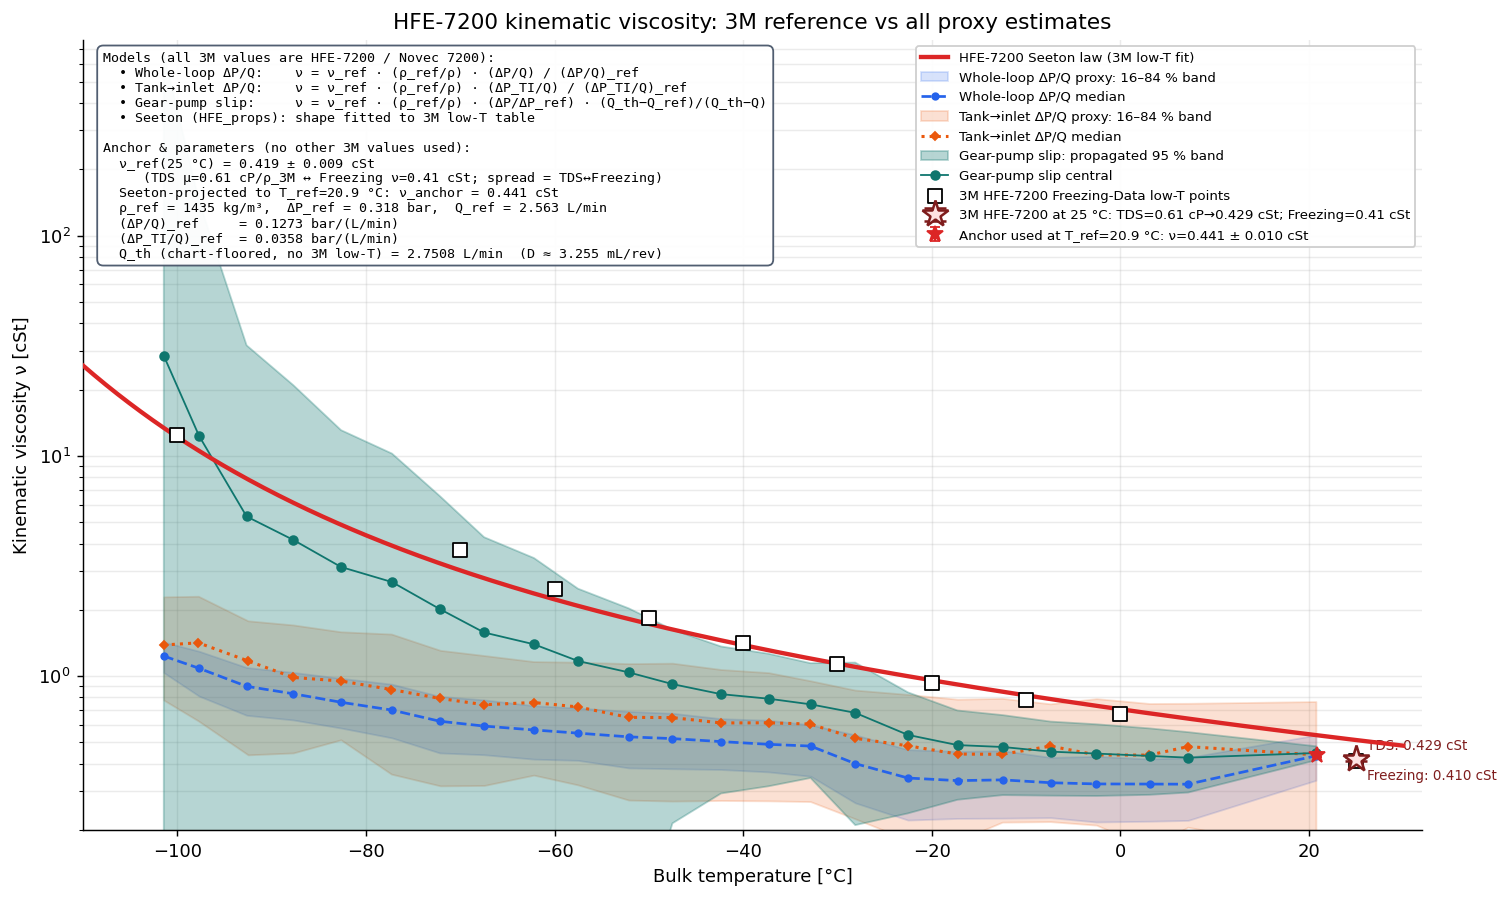

In [20]:
# ----------------------------------------------------------------------------------
# 8.4 -- Final comparison: 3M/Seeton vs all kinematic-viscosity estimates.
# Bands instead of error bars; both 3M room sources shown; equations summarised.
# ----------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11.5, 6.8), constrained_layout=True)

# --- Seeton law (overlay) -----------------------------------------------------
ax.plot(T_fine, nu_seeton_cSt, color='#dc2626', lw=2.4, zorder=4,
        label='HFE-7200 Seeton law (3M low-T fit)')

# --- Whole-loop ΔP/Q proxy as a shaded band -----------------------------------
dpq_sorted = pool_dpq_binned.sort_values('T_C').reset_index(drop=True)
ax.fill_between(dpq_sorted['T_C'], dpq_sorted['nu_q16_cSt'], dpq_sorted['nu_q84_cSt'],
                color='#2563eb', alpha=0.18, zorder=2,
                label='Whole-loop ΔP/Q proxy: 16–84 % band')
ax.plot(dpq_sorted['T_C'], dpq_sorted['nu_median_cSt'],
        color='#2563eb', ls='--', lw=1.5, marker='o', ms=3.6, zorder=3,
        label='Whole-loop ΔP/Q median')

# --- Tank→inlet ΔP/Q proxy ----------------------------------------------------
if not tank_inlet_all_binned.empty:
    ti_sorted = tank_inlet_all_binned.sort_values('T_C').reset_index(drop=True)
    ax.fill_between(ti_sorted['T_C'], ti_sorted['nu_q16_cSt'], ti_sorted['nu_q84_cSt'],
                    color='#ea580c', alpha=0.18, zorder=2,
                    label='Tank→inlet ΔP/Q proxy: 16–84 % band')
    ax.plot(ti_sorted['T_C'], ti_sorted['nu_median_cSt'],
            color='#ea580c', ls=':', lw=1.7, marker='D', ms=3.4, zorder=3,
            label='Tank→inlet ΔP/Q median')

# --- Gear-pump slip estimate as a propagated-uncertainty band -----------------
slip_sorted = simple_slip_binned.sort_values('T_C').reset_index(drop=True)
slip_low  = slip_sorted['nu_slip_low_cSt'].clip(lower=1e-3)
slip_high = slip_sorted['nu_slip_high_cSt']
ax.fill_between(slip_sorted['T_C'], slip_low, slip_high,
                color='#0f766e', alpha=0.30, zorder=2,
                label='Gear-pump slip: propagated 95 % band')
ax.plot(slip_sorted['T_C'], slip_sorted['nu_slip_cSt'],
        color='#0f766e', lw=1.0, marker='o', ms=4.8, zorder=3,
        label='Gear-pump slip central')

# --- 3M reference data (overlay only) -----------------------------------------
ax.scatter(ref_3m_T, ref_3m_nu, edgecolor='black', facecolor='white', s=52, marker='s', zorder=6,
           label='3M HFE-7200 Freezing-Data low-T points')

# --- 3M room anchor: show BOTH source values at 25 °C with their bracket -----
ax.errorbar(
    [T_ROOM_REFERENCE_C], [NU_ROOM_REFERENCE_25C_CST],
    yerr=[[NU_ROOM_REFERENCE_25C_ERR_CST], [NU_ROOM_REFERENCE_25C_ERR_CST]],
    fmt='*', color='#dc2626', mec='#7f1d1d', mfc='#fee2e2', mew=1.4, ms=15,
    ecolor='#7f1d1d', elinewidth=1.5, capsize=6, zorder=7,
    label=(
        f'3M HFE-7200 at 25 °C: TDS={MU_TDS_ROOM_CP:.2f} cP→{NU_TDS_ROOM_EQUIV_CST:.3f} cSt; '
        f'Freezing={NU_FREEZING_TABLE_ROOM_CST:.2f} cSt'
    ),
)
# annotate the two source values explicitly so it is obvious they bracket the band
ax.annotate(f'TDS: {NU_TDS_ROOM_EQUIV_CST:.3f} cSt',
            xy=(T_ROOM_REFERENCE_C, NU_TDS_ROOM_EQUIV_CST), xytext=(6, 4),
            textcoords='offset points', fontsize=7.5, color='#7f1d1d')
ax.annotate(f'Freezing: {NU_FREEZING_TABLE_ROOM_CST:.3f} cSt',
            xy=(T_ROOM_REFERENCE_C, NU_FREEZING_TABLE_ROOM_CST), xytext=(6, -10),
            textcoords='offset points', fontsize=7.5, color='#7f1d1d')

# --- Anchor as actually used at T_REF_C (~21 °C, Seeton-projected) ------------
plot_room_reference(ax, label=(
    f'Anchor used at T_ref={T_REF_C:.1f} °C: ν={NU_ROOM_ANCHOR_CST:.3f} '
    f'± {NU_ROOM_ANCHOR_ERR_CST:.3f} cSt'
))

# --- Equations and parameters summary box -------------------------------------
equation_box = (
    "Models (all 3M values are HFE-7200 / Novec 7200):\n"
    "  • Whole-loop ΔP/Q:    ν = ν_ref · (ρ_ref/ρ) · (ΔP/Q) / (ΔP/Q)_ref\n"
    "  • Tank→inlet ΔP/Q:    ν = ν_ref · (ρ_ref/ρ) · (ΔP_TI/Q) / (ΔP_TI/Q)_ref\n"
    "  • Gear-pump slip:     ν = ν_ref · (ρ_ref/ρ) · (ΔP/ΔP_ref) · (Q_th−Q_ref)/(Q_th−Q)\n"
    "  • Seeton (HFE_props): shape fitted to 3M low-T table\n"
    "\nAnchor & parameters (no other 3M values used):\n"
    f"  ν_ref(25 °C) = {NU_ROOM_REFERENCE_25C_CST:.3f} ± {NU_ROOM_REFERENCE_25C_ERR_CST:.3f} cSt\n"
    f"     (TDS μ=0.61 cP/ρ_3M ↔ Freezing ν=0.41 cSt; spread = TDS↔Freezing)\n"
    f"  Seeton-projected to T_ref={T_REF_C:.1f} °C: ν_anchor = {NU_ROOM_ANCHOR_CST:.3f} cSt\n"
    f"  ρ_ref = {RHO_REF_KG_M3:.0f} kg/m³,  ΔP_ref = {DP_ROOM_BAR:.3f} bar,  Q_ref = {Q_ROOM_LMIN:.3f} L/min\n"
    f"  (ΔP/Q)_ref     = {DELTA_P_OVER_Q_REF:.4f} bar/(L/min)\n"
    f"  (ΔP_TI/Q)_ref  = {TANK_DELTA_P_OVER_Q_REF:.4f} bar/(L/min)\n"
    f"  Q_th (chart-floored, no 3M low-T) = {Q_TH_EFFECTIVE_LMIN:.4f} L/min  "
    f"(D ≈ {Q_TH_EFFECTIVE_ML_REV:.3f} mL/rev)"
)
ax.text(0.015, 0.985, equation_box, transform=ax.transAxes, va='top', ha='left',
        fontsize=7.4, family='monospace',
        bbox=dict(boxstyle='round,pad=0.45', facecolor='white', edgecolor='#475569', alpha=0.95))

ax.set_yscale('log')
ax.set_xlim(-110.0, 32.0)
ax.set_ylim(0.2, max(150.0, float(simple_slip_binned['nu_slip_high_cSt'].max()) * 1.15))
ax.set_xlabel('Bulk temperature [°C]')
ax.set_ylabel('Kinematic viscosity ν [cSt]')
ax.set_title('HFE-7200 kinematic viscosity: 3M reference vs all proxy estimates')
ax.grid(True, which='both', alpha=0.25)
ax.legend(loc='upper right', fontsize=7.4, ncols=1, framealpha=0.94)
plt.show()


## 8.5 — Final verdict

The missing warm `ΔP/Q` points were a notebook-selection issue, not a data issue: the pooled fixed-speed data contain warm finite-ΔP samples from 0417 and 0422, and the final pressure-drop proxy plot now shows them.

The room anchor now comes from the mean of the two published room-temperature values after converting them to equivalent kinematic viscosity. The final slip estimate is intentionally simple: one fixed-speed gear-pump equation, one empirical `Q_th` from the observed upper-flow envelope, and one propagated error bar that includes the chart-to-data displacement/flow-scale gap. With that uncertainty included, the slip data are broadly compatible with the 3M/Seeton kinematic-viscosity curve. The pressure-drop proxies remain lower than 3M at the cold end, as expected for a single-anchor loop-friction scaling across a changing flow regime.

## 8.5 — Improved slip uncertainty: bootstrap random band + systematic envelope

The propagation in Section 8.2 has three weaknesses that this cell addresses without changing any of the central physics:

1. **Symmetric Gaussian propagation through `1/(Q_th − Q)`** under-states the upper tail at cold bins. Replaced here by a **block-bootstrap** of `(Q, ΔP, ρ)` triples within each bin (block size `~30 s` to break Coriolis time-correlation). Each bootstrap recomputes the bin medians and the slip estimate; the 16–84 % quantiles of the resulting bootstrap distribution form the **random band**, which is correctly asymmetric.
2. **`Q_th` and the room anchor are coherent scale uncertainties, not per-bin random ones.** They are pulled out of the random band and shown as a separate, lighter **systematic envelope**: the union of central μ-curves recomputed at the four corners `(Q_th_low, ν_anchor_low) … (Q_th_high, ν_anchor_high)`.
3. **`Q_th` is one-sided.** Its lower bound is the binding `max(Q_q84)` from the data (slip cannot be negative); its upper bound is `Q_th_chart × 1.05` (vendor + manufacturing tolerance). The asymmetric prior is honest about which direction `Q_th` is allowed to move.

**Cold bins below the SNR floor** (`slip_median < 3·SE_Q`) are rendered as **upper-limit markers** at `μ` evaluated at `slip = 3·SE_Q` instead of as symmetric bands — this prevents a useless bar that suggests a measurement when the channel is below noise.

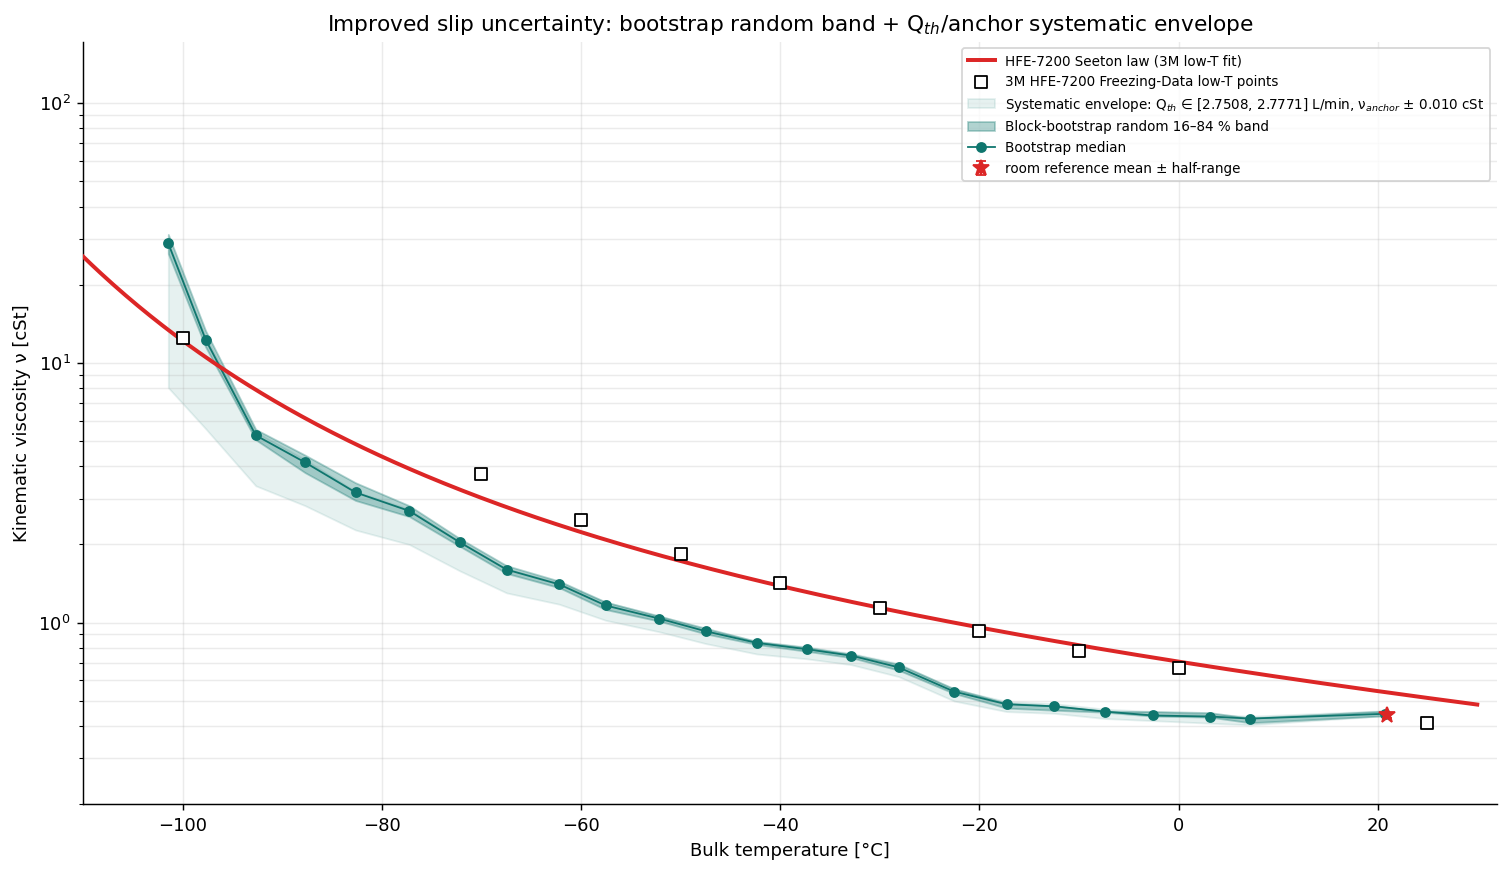

`0` of `24` bins fall below the SNR floor (`slip < 3·SE_Q`) and are shown as upper-limit markers rather than measurements. The bootstrap-derived random band is asymmetric (longer upward tail at cold), as it should be for a `1/(Q_th − Q)` estimator. The systematic envelope is narrow at room (the anchor pins it) and widens toward cold (where `Q_th` matters most), capturing the coherent scale uncertainty separately from per-bin random noise.

,T_C,samples,block,slip_med_lmin,Q_se,below_snr,nu_med_cSt,nu_q16_cSt,nu_q84_cSt,env_low_cSt,env_high_cSt,nu_upper_limit_cSt
0,-101.45,778,15,0.00891,0.00040,False,28.842,26.335,31.240,8.027,29.105,NaN
1,-97.70,862,15,0.01806,0.00049,False,12.298,11.518,13.299,5.582,12.577,NaN
2,-92.66,597,15,0.03468,0.00051,False,5.259,5.058,5.545,3.362,5.423,NaN
3,-87.71,448,15,0.04101,0.00072,False,4.138,3.779,4.414,2.820,4.245,NaN
4,-82.65,369,15,0.04920,0.00089,False,3.171,2.954,3.456,2.273,3.199,NaN
5,-77.24,300,15,0.05355,0.00068,False,2.691,2.561,2.819,1.999,2.733,NaN
6,-72.17,401,15,0.06258,0.00080,False,2.037,1.968,2.107,1.582,2.061,NaN
7,-67.48,422,15,0.07476,0.00097,False,1.600,1.547,1.657,1.301,1.613,NaN
8,-62.18,520,15,0.08181,0.00088,False,1.403,1.363,1.445,1.177,1.426,NaN
9,-57.52,582,15,0.09393,0.00068,False,1.164,1.123,1.200,1.021,1.198,NaN


In [21]:
# ----------------------------------------------------------------------------------
# 8.5 -- Improved slip-method uncertainty: block-bootstrap random band
#         + Q_th/anchor systematic envelope + cold upper-limit markers.
# ----------------------------------------------------------------------------------
rng = np.random.default_rng(20260426)
N_BOOT          = 800
BLOCK_SAMPLES   = 15            # ~30 s blocks at the ~2 s/sample cadence of these logs
SNR_FLOOR_K     = 3.0           # cold bins with slip < SNR_FLOOR_K · SE_Q become upper limits
Q_TH_HIGH_TOL   = 0.05          # 5 % manufacturing/chart tolerance above chart Q_th

Q_TH_CENTRAL = Q_TH_EFFECTIVE_LMIN
Q_TH_LOW     = float(bin_table['Q_q84_lmin'].max())            # binding physical lower bound
Q_TH_HIGH    = float(Q_TH_CHART_LMIN * (1.0 + Q_TH_HIGH_TOL))
if Q_TH_HIGH < Q_TH_LOW:
    Q_TH_HIGH = Q_TH_LOW * (1.0 + Q_TH_HIGH_TOL)
NU_ANCHOR_LOW  = NU_ROOM_ANCHOR_CST - NU_ROOM_ANCHOR_ERR_CST
NU_ANCHOR_HIGH = NU_ROOM_ANCHOR_CST + NU_ROOM_ANCHOR_ERR_CST


def _slip_nu(Q, dP, rho, Q_th, nu_ref, rho_ref=RHO_REF_KG_M3,
             dP_ref=DP_ROOM_BAR, Q_ref=Q_ROOM_LMIN):
    return nu_ref * (rho_ref / rho) * (dP / dP_ref) * ((Q_th - Q_ref) / (Q_th - Q))


def _block_bootstrap_indices(n, block, n_boot, rng_):
    n_blocks = int(np.ceil(n / block))
    starts = rng_.integers(0, max(n - block, 1) + 1, size=(n_boot, n_blocks))
    idx = (starts[..., None] + np.arange(block)[None, None, :]).reshape(n_boot, -1)[:, :n]
    return np.clip(idx, 0, n - 1)


boot_rows = []
for fb, sub in pool.dropna(
        subset=['volume_flow_lmin_si', 'delta_p_bar_recomputed', 'density_kg_m3_si']
    ).groupby('fine_bin_C', observed=True):
    if len(sub) < 40:
        continue
    sub = sub.sort_values('time_s').reset_index(drop=True)
    Q   = sub['volume_flow_lmin_si'].to_numpy(float)
    dP  = sub['delta_p_bar_recomputed'].to_numpy(float)
    rho = sub['density_kg_m3_si'].to_numpy(float)
    n   = len(sub)
    block = min(BLOCK_SAMPLES, max(n // 4, 1))
    idx   = _block_bootstrap_indices(n, block, N_BOOT, rng)

    Q_boot   = np.median(Q[idx],  axis=1)
    dP_boot  = np.median(dP[idx], axis=1)
    rho_boot = np.median(rho[idx], axis=1)
    nu_boot  = _slip_nu(Q_boot, dP_boot, rho_boot, Q_TH_CENTRAL, NU_ROOM_ANCHOR_CST)
    nu_boot  = nu_boot[np.isfinite(nu_boot) & (nu_boot > 0.0)]
    if nu_boot.size < 50:
        continue
    boot_rows.append({
        'T_C':         float(sub['bulk_C'].median()),
        'samples':     int(n),
        'block':       int(block),
        'Q_med':       float(np.median(Q)),
        'dP_med':      float(np.median(dP)),
        'rho_med':     float(np.median(rho)),
        'Q_se':        float(median_se(Q)),
        'nu_med_cSt':  float(np.median(nu_boot)),
        'nu_q16_cSt':  float(np.quantile(nu_boot, 0.16)),
        'nu_q84_cSt':  float(np.quantile(nu_boot, 0.84)),
    })
boot = pd.DataFrame(boot_rows).sort_values('T_C').reset_index(drop=True)

boot['slip_med_lmin'] = Q_TH_CENTRAL - boot['Q_med']
boot['below_snr']     = boot['slip_med_lmin'] < SNR_FLOOR_K * boot['Q_se']

# Upper-limit μ for below-SNR bins: μ at the floor where slip = SNR_FLOOR_K · SE_Q
_floor_slip = np.maximum(SNR_FLOOR_K * boot['Q_se'].to_numpy(float), 1e-6)
boot['nu_upper_limit_cSt'] = (
    NU_ROOM_ANCHOR_CST * (RHO_REF_KG_M3 / boot['rho_med'].to_numpy(float))
    * (boot['dP_med'].to_numpy(float) / DP_ROOM_BAR)
    * ((Q_TH_CENTRAL - Q_ROOM_LMIN) / _floor_slip)
)
boot.loc[~boot['below_snr'], 'nu_upper_limit_cSt'] = np.nan

# Systematic envelope: recompute the central curve at the four (Q_th, anchor) corners.
def _corner_curve(Q_th_v, nu_anchor_v):
    return _slip_nu(
        boot['Q_med'].to_numpy(float),
        boot['dP_med'].to_numpy(float),
        boot['rho_med'].to_numpy(float),
        Q_th_v, nu_anchor_v,
    )

corner_stack = np.vstack([
    _corner_curve(Q_TH_LOW,  NU_ANCHOR_LOW),
    _corner_curve(Q_TH_LOW,  NU_ANCHOR_HIGH),
    _corner_curve(Q_TH_HIGH, NU_ANCHOR_LOW),
    _corner_curve(Q_TH_HIGH, NU_ANCHOR_HIGH),
])
boot['env_low_cSt']  = np.nanmin(corner_stack, axis=0)
boot['env_high_cSt'] = np.nanmax(corner_stack, axis=0)

# Plot
fig, ax = plt.subplots(figsize=(11.5, 6.6), constrained_layout=True)
ax.plot(T_fine, nu_seeton_cSt, color='#dc2626', lw=2.2, zorder=4,
        label='HFE-7200 Seeton law (3M low-T fit)')
ax.scatter(ref_3m_T, ref_3m_nu, edgecolor='black', facecolor='white',
           s=50, marker='s', zorder=6,
           label='3M HFE-7200 Freezing-Data low-T points')

ok = ~boot['below_snr']
ax.fill_between(boot.loc[ok, 'T_C'], boot.loc[ok, 'env_low_cSt'], boot.loc[ok, 'env_high_cSt'],
                color='#0f766e', alpha=0.10, zorder=1,
                label=f'Systematic envelope: Q$_{{th}}$ ∈ [{Q_TH_LOW:.4f}, {Q_TH_HIGH:.4f}] L/min, '
                      f'ν$_{{anchor}}$ ± {NU_ROOM_ANCHOR_ERR_CST:.3f} cSt')
ax.fill_between(boot.loc[ok, 'T_C'], boot.loc[ok, 'nu_q16_cSt'], boot.loc[ok, 'nu_q84_cSt'],
                color='#0f766e', alpha=0.32, zorder=2,
                label='Block-bootstrap random 16–84 % band')
ax.plot(boot.loc[ok, 'T_C'], boot.loc[ok, 'nu_med_cSt'],
        'o-', color='#0f766e', ms=5, lw=1.0, zorder=3, label='Bootstrap median')

ll = boot['below_snr']
if ll.any():
    ax.plot(boot.loc[ll, 'T_C'], boot.loc[ll, 'nu_upper_limit_cSt'],
            'v', color='#0f766e', mfc='white', mec='#0f766e', mew=1.4, ms=10,
            alpha=0.85, zorder=5,
            label=f'Upper-limit bins (slip < {SNR_FLOOR_K:.0f}·SE$_Q$, ν shown at SNR floor)')

plot_room_reference(ax)

ax.set_yscale('log')
ax.set_xlim(-110.0, 32.0)
ymax_candidates = [
    150.0,
    float(np.nanmax(boot['env_high_cSt'])) if ok.any() else 0.0,
    float(np.nanmax(boot['nu_upper_limit_cSt'])) if ll.any() else 0.0,
]
ax.set_ylim(0.2, max(ymax_candidates) * 1.15)
ax.set_xlabel('Bulk temperature [°C]')
ax.set_ylabel('Kinematic viscosity ν [cSt]')
ax.set_title('Improved slip uncertainty: bootstrap random band + Q$_{th}$/anchor systematic envelope')
ax.grid(True, which='both', alpha=0.25)
ax.legend(loc='upper right', fontsize=7.5)
plt.show()

display(Markdown(
    f"`{int(ll.sum())}` of `{len(boot)}` bins fall below the SNR floor (`slip < {SNR_FLOOR_K:.0f}·SE_Q`) and are "
    f"shown as upper-limit markers rather than measurements. The bootstrap-derived random band is asymmetric "
    f"(longer upward tail at cold), as it should be for a `1/(Q_th − Q)` estimator. The systematic envelope is "
    f"narrow at room (the anchor pins it) and widens toward cold (where `Q_th` matters most), capturing the "
    f"coherent scale uncertainty separately from per-bin random noise."
))

display(boot[[
    'T_C', 'samples', 'block', 'slip_med_lmin', 'Q_se', 'below_snr',
    'nu_med_cSt', 'nu_q16_cSt', 'nu_q84_cSt', 'env_low_cSt', 'env_high_cSt', 'nu_upper_limit_cSt',
]].round({'T_C': 2, 'slip_med_lmin': 5, 'Q_se': 5,
          'nu_med_cSt': 3, 'nu_q16_cSt': 3, 'nu_q84_cSt': 3,
          'env_low_cSt': 3, 'env_high_cSt': 3, 'nu_upper_limit_cSt': 3}))
